# Notebook 02 — KPI Forecasting (SpiriCom · Huawei PFE)

---

## Overview

This notebook implements an **end-to-end KPI analytics and forecasting pipeline** for the SpiriCom telecom intelligence platform.  
It focuses on **session behavior classification**, **5G traffic forecasting**, and **brand-level demand prediction**, combining both machine learning and statistical time series methods.

---

## 1. Data Preparation & Target Engineering

We start by defining and validating key prediction targets:

### 1.1 Session Flag (Binary Classification Target)
- Derived from session activity indicators or duration columns
- Automatically corrected if label direction is inverted
- Ensures consistent meaning: `1 = active session`

### 1.2 5G Traffic Series
- Extracted from raw telecom counters
- Automatically detects log-transformed vs raw scale
- Aggregated into a **daily time series**

### 1.3 Brand-Level Traffic
- Aggregated per brand per day
- Focused on top N most active brands

---

## 2. Train / Test Splitting Strategy

A **time-aware chronological split** is applied:

| Split | Proportion | Purpose |
|-------|------------|---------|
| **Training** | 80% | Model fitting and validation |
| **Testing** | 20% | Final evaluation |

**Benefits:**

-  No data leakage
-  Realistic forecasting evaluation
-  Temporal consistency for all models

---

## 3. Session Behavior Modeling (Classification)

Two scenarios are handled based on data availability:

### 3.1 Panel Mode (Rich User History)

| Feature Type | Examples |
|--------------|----------|
| **Multi-lag features** | 1, 2, 3, 7 days |
| **Rolling averages** | Mean, std, min, max |
| **User-level aggregation** | Per-subscriber statistics |
| **Sequence-aware modeling** | Temporal patterns |

### 3.2 Cross-sectional Mode (Limited History)

- Uses static subscriber features only
- Removes constant / non-informative columns

### 3.3 Model Used: XGBoost Classifier

| Configuration | Value |
|---------------|-------|
| **Algorithm** | XGBoost Classifier |
| **Imbalance handling** | `scale_pos_weight` |
| **Optimization metric** | PR-AUC |
| **Threshold tuning** | Validation F1-score maximization |

### 3.4 Outputs

| Output | Description |
|--------|-------------|
| **Prediction** | Active / inactive session classification |
| **Metrics** | F1, Precision, Recall, ROC-AUC |

---

## 4. 5G Traffic Forecasting Models

Three different approaches are implemented and compared:

### 4.1 Prophet (Meta)

**Mathematical Formulation:**

$$y(t) = g(t) + s(t) + h(t) + \epsilon(t)$$

Where:
- $g(t)$ = Trend (piecewise linear or logistic growth)
- $s(t)$ = Seasonality (Fourier series)
- $h(t)$ = Holiday effects
- $\epsilon(t)$ = Error term

**Tested Variants:**

| Variant | Scale | Type |
|---------|-------|------|
| Raw scale | Multiplicative | Seasonality |
| Log1p scale | Additive | Seasonality |

---

### 4.2 ARIMA (Statistical Baseline)

**Mathematical Formulation:**

$$y_t = \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \theta_1 \epsilon_{t-1} + \dots + \theta_q \epsilon_{t-q} + \epsilon_t$$

| Parameter | Meaning |
|-----------|---------|
| $p$ | Auto-regressive order |
| $d$ | Differencing order |
| $q$ | Moving average order |

**Implementation:**
- Auto-selected `(p, d, q)` parameters
- Applied on log-transformed data
- Captures autocorrelation structure

---

### 4.3 XGBoost Regression

**Feature Engineering:**

| Feature Category | Examples |
|------------------|----------|
| **Lag features** | 1, 2, 3, 7, 14 days |
| **Rolling statistics** | Mean & std |
| **Calendar features** | Day-of-week, month, week |

**Advantage:**
- Learns nonlinear temporal dependencies
- Captures complex interactions between features

---

## 5. Model Evaluation Strategy

Each model is evaluated using the following metrics:

### 5.1 Error Metrics

| Metric | Formula | Purpose |
|--------|---------|---------|
| **MAE** | $\frac{1}{n}\sum_{t=1}^n \|y_t - \hat{y}_t\|$ | Average absolute error |
| **RMSE** | $\sqrt{\frac{1}{n}\sum_{t=1}^n (y_t - \hat{y}_t)^2}$ | Penalizes large errors |
| **MAPE** | $\frac{1}{n}\sum_{t=1}^n \left|\frac{y_t - \hat{y}_t}{y_t}\right| \times 100$ | Percentage error |
| **sMAPE** | $\frac{2}{n}\sum_{t=1}^n \frac{|y_t - \hat{y}_t|}{|y_t| + |\hat{y}_t|} \times 100$ | Symmetric percentage error |
| **$R^2$** | $1 - \frac{\sum (y_t - \hat{y}_t)^2}{\sum (y_t - \bar{y})^2}$ | Variance explained |

### 5.2 Selection Logic

```mermaid
graph TD
    A[All Models] --> B[Calculate MAE]
    B --> C[Select model with lowest MAE]
    C --> D{Check MAPE < 20%?}
    D -->|Yes| E[ Model Approved]
    D -->|No| F[ Review Model]

In [1]:
# 0. IMPORTS, STYLE & PATHS
import pandas as pd
import numpy as np
import json, warnings, joblib
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    accuracy_score, mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report
)
import xgboost as xgb
from prophet import Prophet
from prophet.serialize import model_to_json

try:
    from pmdarima import auto_arima
    PMDARIMA_OK = True
except ImportError:
    PMDARIMA_OK = False
    print('WARNING: pmdarima not installed - ARIMA section will be skipped')
    print('         pip install pmdarima')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

PROC_DIR  = Path('data/processed')
FIG_DIR   = Path('data/outputs/figures')
OUT_DIR   = Path('data/outputs')
MODEL_DIR = Path('models/prediction')
for d in [FIG_DIR, OUT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Huawei Brand Palette ──────────────────────────────────────
HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', cyan='#00C3FF',
          green='#22C55E', amber='#F59E0B', purple='#8B5CF6',
          orange='#F97316', muted='#6B7280')
PALETTE = [HW['blue'], HW['red'], HW['cyan'], HW['green'],
           HW['amber'], HW['purple'], HW['orange'], HW['navy']]

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.edgecolor':'#E5E7EB', 'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'axes.grid.axis':'y', 'grid.color':'#F3F4F6', 'grid.linewidth':0.8,
    'axes.labelcolor':HW['navy'], 'axes.labelweight':'bold', 'axes.labelsize':11,
    'axes.titlesize':13, 'axes.titleweight':'bold', 'axes.titlecolor':HW['navy'],
    'xtick.color':HW['muted'], 'ytick.color':HW['muted'],
    'xtick.labelsize':9, 'ytick.labelsize':9,
    'legend.fontsize':9, 'legend.framealpha':0.92, 'legend.edgecolor':'#E5E7EB',
    'font.family':'DejaVu Sans', 'figure.dpi':120,
    'savefig.dpi':300, 'savefig.bbox':'tight', 'savefig.facecolor':'white',
})
pio.templates.default = 'plotly_white'
PLOTLY_LAYOUT = dict(
    font=dict(family='Arial, sans-serif', color=HW['navy']),
    paper_bgcolor='white', plot_bgcolor='white',
    title_font=dict(size=16, color=HW['navy']), colorway=PALETTE,
    margin=dict(l=60, r=40, t=80, b=60),
    legend=dict(bgcolor='rgba(255,255,255,.9)', bordercolor='#E5E7EB', borderwidth=1),
)

def add_watermark(fig, text='SpiriCom - Huawei Technologies Tunisia'):
    fig.text(0.99, 0.01, text, ha='right', va='bottom',
             fontsize=7, color=HW['muted'], style='italic',
             transform=fig.transFigure)

def save_fig(name):
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'  Saved: {path}')

# NB02-1: distinct name so a metric variable can never shadow it
def mape_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    return np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]) * 100

# NB02-2: every metric variable initialised once, here.
f1_s = auc_s = acc_s = prec_s = rec_s = None
prophet_mae = prophet_rmse = prophet_mape = prophet_smape = None
arima_mae = arima_rmse = arima_mape = arima_smape = None
arima_order = None
xgb_reg_mae = xgb_reg_rmse = xgb_reg_mape = xgb_reg_r2 = xgb_reg_smape = None
prophet_fc = None
SESSION_MODE = None      # 'panel' (next-day) or 'row-level (LEAKY)'

print('Setup complete')
print(f'Model outputs: {MODEL_DIR.resolve()}')
print(f'Figures:       {FIG_DIR.resolve()}')


Setup complete
Model outputs: C:\Users\c50057188\Desktop\PFE_Ouerghi\models\prediction
Figures:       C:\Users\c50057188\Desktop\PFE_Ouerghi\data\outputs\figures


## Section 1 — Load Data & Feature Audit

In [2]:
# ── 1.1 Load kpi_clean.parquet ────────────────────────────────
df = pd.read_parquet(PROC_DIR / 'kpi_clean.parquet')
df.columns = df.columns.str.lower()          # normalise FIRST, then test
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

has_5g      = any('5g' in c and 'traffic' in c for c in df.columns)
has_session = 'session_flag' in df.columns
has_brand   = 'brand'        in df.columns
has_ts      = 'timestamp'    in df.columns
print(f'  Has traffic_5g   : {has_5g}')
print(f'  Has session_flag : {has_session}')
print(f'  Has brand        : {has_brand}')
print(f'  Has timestamp    : {has_ts}')


Loaded: 4,898 rows x 122 columns
  Has traffic_5g   : True
  Has session_flag : True
  Has brand        : True
  Has timestamp    : True


In [3]:
# ── 1.2 Column audit ──────────────────────────────────────────
null_pct = df.isnull().mean() * 100
audit = pd.DataFrame({
    'dtype'    : df.dtypes,
    'null_pct' : null_pct.round(2),
    'n_unique' : df.nunique(),
}).sort_values('null_pct', ascending=False)
print(audit.to_string())
print(f'\nMax null % in any retained column: {null_pct.max():.1f}% (should be < 80%)')

# NB02-7: a missing timestamp is a hard error - a fabricated time axis
# would make every "time series" result downstream fictional.
if 'timestamp' not in df.columns:
    raise ValueError(
        'No timestamp column in kpi_clean.parquet. Fix NB00 so the TIMEE '
        'column is parsed and renamed - do NOT fabricate a time axis.'
    )

df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')
n_bad = df['timestamp'].isna().sum()
print(f'Missing/unparseable timestamps dropped: {n_bad}')
df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
print(f'Timestamp range: {df["timestamp"].min()} -> {df["timestamp"].max()}')
print(f'Rows after timestamp filter: {len(df):,}')

df['ds']   = df['timestamp']
df['date'] = df['timestamp'].dt.date


                                                     dtype  null_pct  n_unique
timestamp                                   datetime64[ns]    0.0000       263
iu_auth_ciphering_sr                               float64    0.0000         5
iu_pdp_context_procedure_activation_sr             float64    0.0000        95
iu_attach_sr                                       float64    0.0000        95
s1_mme_df_eps_bearer_context_activation_sr         float64    0.0000        87
s1_mme_auth_sr                                     float64    0.0000        23
s1_mme_sr                                          float64    0.0000       160
quic_downlink_out_of_order_rate                    float64    0.0000       195
quic_uplink_out_of_order_rate                      float64    0.0000        58
quic_downlink_packet_loss_rate                     float64    0.0000       371
quic_uplink_packet_loss_rate                       float64    0.0000       434
udp_downlink_jitter                                f

## Section 2 — Target Engineering

In [4]:
# ==============================================================
# 2.1 Session Target Engineering
# --------------------------------------------------------------
# This section validates or creates the binary target variable
# "session_flag", which indicates whether a mobile session is
# active (1) or inactive (0).
#
# The target variable will later be used for supervised
# classification models.
# ==============================================================

# --------------------------------------------------------------
# Case 1:
# The dataset already contains a session_flag column.
# --------------------------------------------------------------
if 'session_flag' in df.columns:

    # Display the distribution of both classes.
    # This helps detect class imbalance before training.
    print("session_flag distribution:")
    print(df['session_flag'].value_counts())

    # Compute the proportion of active sessions.
    print(f"Active rate: {df['session_flag'].mean():.3f}")

    # ----------------------------------------------------------
    # Select a traffic-related feature that can validate whether
    # the labels have the correct meaning.
    #
    # Active sessions should normally produce more traffic.
    # ----------------------------------------------------------
    dou_col = next(
        (c for c in ['dou_total', 'traffic_4g'] if c in df.columns),
        None
    )

    if dou_col:

        # Compute the average traffic generated by each class.
        mean_0 = df.loc[df['session_flag'] == 0, dou_col].mean()
        mean_1 = df.loc[df['session_flag'] == 1, dou_col].mean()

        # ------------------------------------------------------
        # Verify whether the class labels are correctly assigned.
        #
        # Expected relationship:
        #
        # Average Traffic(Session=1)
        #      >
        # Average Traffic(Session=0)
        #
        # If the opposite is observed, the labels are inverted.
        # ------------------------------------------------------
        if mean_0 > mean_1:

            print(
                f"WARNING: session_flag appears inverted "
                f"(group 0 has higher {dou_col}: "
                f"{mean_0:.2f} vs {mean_1:.2f})"
            )

            print("Inverting session_flag so that 1 represents an active session.")

            # Reverse binary labels:
            #
            # 0 → 1
            # 1 → 0
            df['session_flag'] = 1 - df['session_flag']

            print(f"New active rate: {df['session_flag'].mean():.3f}")

        else:

            print(
                f"Flag direction confirmed "
                f"(group 1 has higher {dou_col}: "
                f"{mean_1:.2f} vs {mean_0:.2f})"
            )

    # Store the target variable name for later use.
    SESSION_TARGET = 'session_flag'


# --------------------------------------------------------------
# Case 2:
# session_flag is not available.
#
# Create it from the session duration column.
# --------------------------------------------------------------
else:

    # Search for any column containing the word "duration".
    dur_col = next(
        (c for c in df.columns if 'duration' in c),
        None
    )

    if dur_col:

        # ------------------------------------------------------
        # A session is considered active if its duration
        # is strictly greater than zero.
        #
        # Mathematical definition:
        #
        # session_flag =
        #      1  if duration > 0
        #      0  otherwise
        # ------------------------------------------------------
        df['session_flag'] = (df[dur_col] > 0).astype(int)

        print(f"session_flag derived from '{dur_col}'.")

        SESSION_TARGET = 'session_flag'

    else:

        # No suitable column was found.
        # Session-based analyses will therefore be skipped.
        SESSION_TARGET = None

        print(
            "WARNING: No session_flag or duration column found. "
            "Session forecasting section will be skipped."
        )

session_flag distribution:
session_flag
0    4654
1     244
Name: count, dtype: int64
Active rate: 0.050
Flag direction confirmed (group 1 has higher dou_total: 925866908.35 vs 508095036.82)


In [5]:
# ==============================================================
# 2.2 Daily 5G Traffic Time Series Construction
# --------------------------------------------------------------
# This section builds the daily 5G traffic time series that will
# later be used for forecasting models such as Prophet and ARIMA.
#
# The procedure includes:
#   1. Detecting the 5G traffic column.
#   2. Identifying whether traffic values are log-transformed.
#   3. Converting traffic back to its original scale if needed.
#   4. Aggregating session-level traffic by day.
# ==============================================================

# --------------------------------------------------------------
# Search for a column containing both "5g" and "traffic".
# This makes the notebook robust to slight differences in
# column naming across datasets.
# --------------------------------------------------------------
traffic_5g_col = next(
    (c for c in df.columns if '5g' in c and 'traffic' in c),
    None
)

# --------------------------------------------------------------
# Manual override.
#
# Set to:
#   True  -> values are already known to be log-transformed
#   False -> values are known to be raw traffic
#   None  -> automatically detect the scale
# --------------------------------------------------------------
TRAFFIC_IS_LOG = None

daily_5g = None

# --------------------------------------------------------------
# Continue only if a valid traffic column exists.
# --------------------------------------------------------------
if traffic_5g_col:

    # Convert values to floating-point numbers to ensure
    # numerical consistency during processing.
    vals = df[traffic_5g_col].astype(float)

    # ----------------------------------------------------------
    # Automatic scale detection.
    #
    # Raw telecom traffic values (Bytes, KB, MB, GB)
    # are generally much larger than logarithmic values.
    #
    # If the maximum value is below 30, the column is assumed
    # to contain log1p-transformed traffic.
    # ----------------------------------------------------------
    if TRAFFIC_IS_LOG is None:
        TRAFFIC_IS_LOG = vals.max() < 30

    print(f"5G traffic column : {traffic_5g_col}")
    print(f"Maximum row value : {vals.max():.3f}")
    print(f"TRAFFIC_IS_LOG    : {TRAFFIC_IS_LOG}")

    # ----------------------------------------------------------
    # If the traffic is stored using log1p(x),
    # recover the original values using:
    #
    # x = exp(y) - 1
    #
    # implemented with NumPy's expm1() function.
    # ----------------------------------------------------------
    df["_t5g_raw"] = (
        np.expm1(vals)
        if TRAFFIC_IS_LOG
        else vals
    )

    # ----------------------------------------------------------
    # Aggregate all session-level traffic values by date.
    #
    # Mathematical formulation:
    #
    # DailyTraffic(d)
    #     =
    # Σ Traffic(session_i)
    #
    # for every session recorded on day d.
    # ----------------------------------------------------------
    daily_5g = (
        df.groupby("date")["_t5g_raw"]
          .sum()
          .reset_index()
          .rename(columns={
              "_t5g_raw": "traffic_5g",
              "date": "ds"
          })
    )

    # Convert the date column into datetime format.
    daily_5g["ds"] = pd.to_datetime(daily_5g["ds"])

    # Sort observations chronologically.
    daily_5g = (
        daily_5g
        .sort_values("ds")
        .reset_index(drop=True)
    )

    # Display summary information.
    print(f"Daily 5G series contains {len(daily_5g)} days.")

    print(
        daily_5g["traffic_5g"]
        .describe()
        .round(2)
    )

# --------------------------------------------------------------
# No suitable 5G traffic column found.
# --------------------------------------------------------------
else:

    print(
        "WARNING: No 5G traffic column detected. "
        "Time-series forecasting for 5G traffic will be skipped."
    )

5G traffic column : traffic_5g
Maximum row value : 2438473279.000
TRAFFIC_IS_LOG    : False
Daily 5G series contains 263 days.
count          263.0000
mean     342356241.2800
std      860755092.2900
min            308.0000
25%        1160988.0000
50%        3289466.0000
75%      168663946.0000
max     7616107644.0000
Name: traffic_5g, dtype: float64


In [6]:
# ==============================================================
# 2.3 Brand-Level Daily Traffic Aggregation
# --------------------------------------------------------------
# This section creates a daily traffic dataset grouped by
# smartphone brand.
#
# The objective is to analyse and forecast network traffic
# separately for the most representative device manufacturers.
# ==============================================================

# --------------------------------------------------------------
# Select the traffic variable.
#
# Priority:
#   1. Restored 5G traffic (_t5g_raw)
#   2. Total traffic column
#   3. DoU (Data of Usage)
# --------------------------------------------------------------
brand_traffic_col = (
    "_t5g_raw"
    if traffic_5g_col
    else next(
        (c for c in df.columns
         if "traffic" in c and "total" in c),
        None
    )
) or next(
    (c for c in df.columns if c == "dou_total"),
    None
)

brand_daily = None
BRAND_TARGET = None

# --------------------------------------------------------------
# Continue only if both the smartphone brand and a traffic
# variable are available.
# --------------------------------------------------------------
if "brand" in df.columns and brand_traffic_col:

    # ----------------------------------------------------------
    # If the selected traffic column is not the restored
    # 5G traffic, verify whether it is log-transformed.
    #
    # When necessary, recover the original values using:
    #
    # x = exp(y) - 1
    # ----------------------------------------------------------
    if brand_traffic_col != "_t5g_raw":

        bvals = df[brand_traffic_col].astype(float)

        if bvals.max() < 30:
            df["_brand_raw"] = np.expm1(bvals)
        else:
            df["_brand_raw"] = bvals

        use_col = "_brand_raw"
        BRAND_TARGET = brand_traffic_col

    else:

        use_col = "_t5g_raw"
        BRAND_TARGET = traffic_5g_col

    # ----------------------------------------------------------
    # Select the five most frequent smartphone brands.
    #
    # Focusing on the dominant brands improves statistical
    # reliability and avoids sparse time series.
    # ----------------------------------------------------------
    top_brands = (
        df["brand"]
        .value_counts()
        .head(5)
        .index
        .tolist()
    )

    # ----------------------------------------------------------
    # Aggregate traffic by:
    #   • Date
    #   • Smartphone brand
    #
    # Mathematical formulation:
    #
    # Traffic(day, brand)
    #      =
    # Σ Traffic(session)
    #
    # for every session associated with that brand.
    # ----------------------------------------------------------
    brand_daily = (
        df[df["brand"].isin(top_brands)]
          .groupby(["date", "brand"])[use_col]
          .sum()
          .reset_index()
          .rename(columns={
              use_col: "traffic",
              "date": "ds"
          })
    )

    # Convert dates into datetime format.
    brand_daily["ds"] = pd.to_datetime(brand_daily["ds"])

    print(
        f"Brand daily table contains "
        f"{len(brand_daily)} observations."
    )

    print(f"Selected brands: {top_brands}")

# --------------------------------------------------------------
# Missing information.
# --------------------------------------------------------------
else:

    print(
        "WARNING: Brand or traffic column is missing. "
        "Brand-level forecasting cannot be performed."
    )

Brand daily table contains 869 observations.
Selected brands: ['SAMSUNG', 'XIAOMI', 'INFINIX', 'OPPO', 'APPLE']


## Section 3 — Train / Test Split (chronological)

In [7]:
# ==============================================================
# Section 3 — Chronological Train/Test Split
# --------------------------------------------------------------
# This section divides the dataset into training and testing
# subsets while preserving the chronological order of the data.
#
# Chronological splitting is essential for time-series analysis
# because future observations must never be used to predict
# past events.
# ==============================================================

# --------------------------------------------------------------
# Define the proportion of data allocated for model training.
#
# Here:
#   • 80% → Training set
#   • 20% → Testing set
# --------------------------------------------------------------
SPLIT_RATIO = 0.80

# --------------------------------------------------------------
# Compute the index corresponding to the split point.
#
# Mathematical formulation:
#
# SplitIndex = floor(N × SplitRatio)
#
# where:
#   N = total number of observations.
# --------------------------------------------------------------
split_idx = int(len(df) * SPLIT_RATIO)

# Retrieve the timestamp corresponding to the split point.
split_date = df["timestamp"].iloc[split_idx]

# --------------------------------------------------------------
# Create the chronological training dataset.
#
# Contains all observations before the split date.
# --------------------------------------------------------------
df_train = df.iloc[:split_idx].copy()

# --------------------------------------------------------------
# Create the chronological testing dataset.
#
# Contains future observations used only for evaluation.
# --------------------------------------------------------------
df_test = df.iloc[split_idx:].copy()

# Display summary information.
print(f"Split date : {split_date}")

print(
    f"Train rows : {len(df_train):,} "
    f"({len(df_train)/len(df)*100:.0f}%)"
)

print(
    f"Test rows  : {len(df_test):,} "
    f"({len(df_test)/len(df)*100:.0f}%)"
)

# --------------------------------------------------------------
# Apply the same chronological split to the aggregated
# daily 5G traffic time series.
# --------------------------------------------------------------
if daily_5g is not None:

    split5g = int(len(daily_5g) * SPLIT_RATIO)

    train_5g = daily_5g.iloc[:split5g].copy()

    test_5g = daily_5g.iloc[split5g:].copy()

    # ----------------------------------------------------------
    # Forecast horizon
    #
    # The number of future days that forecasting models
    # must predict corresponds to the size of the testing set.
    # ----------------------------------------------------------
    HORIZON = len(test_5g)

    print(
        f"5G traffic split : "
        f"Train = {len(train_5g)} days | "
        f"Test = {len(test_5g)} days"
    )

# --------------------------------------------------------------
# If the daily time series is unavailable, define a default
# forecasting horizon of 30 days.
# --------------------------------------------------------------
else:

    HORIZON = 30

Split date : 2025-10-15 00:00:00
Train rows : 3,918 (80%)
Test rows  : 980 (20%)
5G traffic split : Train = 210 days | Test = 53 days


## Section A — Session Flag classification

In [8]:
# ==============================================================
# Section A — Session Flag Classification
# --------------------------------------------------------------
# This section builds a machine learning pipeline to predict
# session activity (session_flag).
#
# Depending on data density per subscriber, the model is built
# either in:
#   • PANEL MODE (longitudinal time series per user)
#   • CROSS-SECTIONAL MODE (static classification)
# ==============================================================

# --------------------------------------------------------------
# If session target is unavailable, skip this section.
# --------------------------------------------------------------
if SESSION_TARGET is None:

    print("Session target unavailable - skipping Section A")

else:

    # ----------------------------------------------------------
    # Compute dataset-level statistics
    # ----------------------------------------------------------
    n_days = df["date"].nunique()

    if "msisdn" in df.columns:

        # Number of unique observed days per subscriber
        obs_per_sub = df.groupby("msisdn")["date"].nunique()
        median_obs = float(obs_per_sub.median())

    else:
        obs_per_sub, median_obs = pd.Series(dtype=int), 0.0

    print(
        f"Distinct days: {n_days} | "
        f"subscribers: {len(obs_per_sub):,} | "
        f"median observed days per subscriber: {median_obs:.1f}"
    )

    # ==========================================================
    # DECISION: PANEL MODE vs CROSS-SECTIONAL MODE
    # ==========================================================
    if median_obs >= 5:

        # ------------------------------------------------------
        # PANEL MODE: longitudinal modeling per subscriber
        # ------------------------------------------------------
        SESSION_MODE = "panel"

        # Define aggregated KPI columns
        agg_map = {
            c: (c, "sum")
            for c in ["dou_total", "duration", "traffic_4g"]
            if c in df.columns
        }

        # ------------------------------------------------------
        # Aggregate at (subscriber, date) level
        # ------------------------------------------------------
        panel = (
            df.groupby(["msisdn", "date"])
              .agg(active=("session_flag", "max"), **agg_map)
              .reset_index()
        )

        # ------------------------------------------------------
        # Create full daily timeline per subscriber
        # ------------------------------------------------------
        all_days = pd.date_range(
            df["date"].min(),
            df["date"].max(),
            freq="D"
        ).date

        idx = pd.MultiIndex.from_product(
            [panel["msisdn"].unique(), all_days],
            names=["msisdn", "date"]
        )

        panel = (
            panel.set_index(["msisdn", "date"])
                  .reindex(idx, fill_value=0)
                  .reset_index()
                  .sort_values(["msisdn", "date"])
                  .reset_index(drop=True)
        )

        g = panel.groupby("msisdn")

        feat_cols_session = []

        # ------------------------------------------------------
        # Lag feature engineering
        # x(t-k) captures temporal dependency
        # ------------------------------------------------------
        for lag in [1, 2, 3, 7]:

            panel[f"active_lag{lag}"] = g["active"].shift(lag)
            feat_cols_session.append(f"active_lag{lag}")

            for c in agg_map:

                panel[f"{c}_lag{lag}"] = g[c].shift(lag)
                feat_cols_session.append(f"{c}_lag{lag}")

        # ------------------------------------------------------
        # Rolling mean feature (7-day engagement stability)
        # ------------------------------------------------------
        panel["active_roll7"] = g["active"].transform(
            lambda s: s.shift(1).rolling(7, min_periods=3).mean()
        )

        feat_cols_session.append("active_roll7")

        # Remove missing values caused by lagging
        panel = panel.dropna(subset=feat_cols_session).reset_index(drop=True)

        # ------------------------------------------------------
        # Chronological train/test split
        # ------------------------------------------------------
        dates_sorted = sorted(panel["date"].unique())
        cut = dates_sorted[int(len(dates_sorted) * SPLIT_RATIO)]

        tr = panel[panel["date"] < cut]
        te = panel[panel["date"] >= cut]

        X_train_s = tr[feat_cols_session]
        y_train_s = tr["active"].astype(int)

        X_test_s = te[feat_cols_session]
        y_test_s = te["active"].astype(int)

        print(f"Panel rows: {len(panel):,} | split date: {cut}")

    else:

        # ======================================================
        # CROSS-SECTIONAL MODE
        # ======================================================
        SESSION_MODE = "cross-sectional"

        print(
            "Each subscriber is observed ~once -> "
            "time-series prediction is not feasible."
        )

        print(
            "Classifying session_flag using subscriber-level features."
        )

        print(
            "Note: verify definition of session_flag with data owner."
        )

        # ------------------------------------------------------
        # Remove constant columns (zero variance features)
        # ------------------------------------------------------
        const_cols = [
            c for c in df.columns
            if df[c].nunique(dropna=False) <= 1
        ]

        print(f"Constant columns dropped ({len(const_cols)}): {const_cols}")

        # ------------------------------------------------------
        # Excluded identifiers and leakage-prone fields
        # ------------------------------------------------------
        EXCLUDE = (
            {
                "session_flag", "timestamp", "date", "ds",
                "msisdn", "imsi", "home_cell", "home_site",
                "site_name", "apn", "longitude", "latitude",
                "_t5g_raw", "_brand_raw"
            }
            | set(const_cols)
        )

        num_cols2 = df.select_dtypes(include=[np.number]).columns

        feat_cols_session = [
            c for c in num_cols2 if c not in EXCLUDE
        ]

        X_train_s = df_train[feat_cols_session].fillna(0)
        y_train_s = df_train[SESSION_TARGET].astype(int)

        X_test_s = df_test[feat_cols_session].fillna(0)
        y_test_s = df_test[SESSION_TARGET].astype(int)

    # ----------------------------------------------------------
    # Final summary
    # ----------------------------------------------------------
    print(
        f"Mode: {SESSION_MODE} | "
        f"features: {len(feat_cols_session)}"
    )

    print(f"Train class balance: {y_train_s.value_counts().to_dict()}")
    print(f"Test class balance : {y_test_s.value_counts().to_dict()}")

Distinct days: 263 | subscribers: 4,896 | median observed days per subscriber: 1.0
Each subscriber is observed ~once -> time-series prediction is not feasible.
Classifying session_flag using subscriber-level features.
Note: verify definition of session_flag with data owner.
Constant columns dropped (9): ['imsi', 'mcc', 'mnc', 'roaming_direction', 'layer1name', 'ccr_u', 'ccr_i_gx', 'ccr_u_gx', 'hour']
Mode: cross-sectional | features: 93
Train class balance: {0: 3728, 1: 190}
Test class balance : {0: 926, 1: 54}



Each subscriber is observed ~once -> time-series prediction is not feasible.
Classifying session_flag using subscriber-level features.
Note: verify definition of session_flag with data owner.
Constant columns dropped (9): ['imsi', 'mcc', 'mnc', 'roaming_direction', 'layer1name', 'ccr_u', 'ccr_i_gx', 'ccr_u_gx', 'hour']
Mode: cross-sectional | features: 93
Train class balance: {0: 3728, 1: 190}
Test class balance : {0: 926, 1: 54}


# A.2 XGBoost Classifier — Imbalance-Aware Session Prediction

## 1. Objective

The objective of this step is to train a **binary classification model using XGBoost** to predict the session activity status (`session_flag`) while explicitly handling:

- Severe class imbalance
- Temporal leakage risks
- Optimal decision threshold selection
- Realistic telecom evaluation metrics

This model represents the core predictive engine of the **Session Intelligence** module in the SpiriCom platform.

---

## 2. Why XGBoost?

XGBoost (Extreme Gradient Boosting) is selected for the following reasons:

- Handles non-linear relationships efficiently
- Performs well on tabular telecom KPI data
- Robust to missing values
- Supports class imbalance weighting via `scale_pos_weight`
- Provides strong performance on heterogeneous network data

---

## 3. Imbalance Problem in Telecom Data

In real telecom datasets:

$$P(y=1) \ll P(y=0)$$

where:

- $y=1$: Active session
- $y=0$: Inactive session

Typically, only a small fraction of sessions are active (≈5%). This creates a **highly imbalanced classification problem**, which can bias the model toward predicting the majority class (inactive sessions).

---

## 4. Validation Strategy — Temporal Split

To avoid **data leakage**, a **time-based validation split** is applied:

$$\text{Train} \rightarrow \text{Sub-train} + \text{Validation (last 20%)}$$

This simulates real-world deployment conditions, where future behavior must be predicted from past data.

---

## 5. Class Imbalance Handling

### 5.1 Scale Pos Weight

XGBoost compensates for imbalance using:

$$scale\_pos\_weight = \frac{N_{negative}}{N_{positive}}$$

This increases the penalty for misclassifying the minority class (active sessions), ensuring the model does not collapse into predicting only the majority class.

---

## 6. Model Configuration

The model is configured with the following hyperparameters:

| Hyperparameter | Value | Justification |
|----------------|-------|---------------|
| `n_estimators` | 300 | Number of boosting rounds |
| `max_depth` | 6 | Controls model complexity |
| `learning_rate` | 0.08 | Step size for gradient updates |
| `subsample` | 0.85 | Prevents overfitting by row sampling |
| `colsample_bytree` | 0.8 | Feature sampling per tree |
| `eval_metric` | AUC-PR | Appropriate for imbalanced datasets |

---

## 7. Why AUC-PR Instead of Accuracy?

In imbalanced datasets:

- **Accuracy is misleading** — a model predicting all zeros can still achieve high accuracy
- Instead, we use **Precision-Recall AUC**

### Precision-Recall AUC

$$PR\text{-}AUC = \int_0^1 Precision(Recall) \, d(Recall)$$

This metric focuses on the model's ability to correctly detect **positive (active) sessions**, which are rare but operationally important.

---

## 8. Decision Threshold Optimization

Instead of using a fixed threshold (0.5), the optimal threshold is selected using the validation set.

### Steps:

1. Compute probability predictions:

$$\hat{y} = P(y=1 \mid x)$$

2. Evaluate Precision-Recall curve:

$$(Precision, Recall, Threshold)$$

3. Compute F1-score:

$$F1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$$

4. Select threshold that maximizes F1:

$$THRESH = \arg\max(F1)$$

This ensures the best trade-off between false positives and false negatives.

---

## 9. Evaluation Metrics

The model is evaluated using multiple complementary metrics:

### 9.1 Accuracy

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

### 9.2 Precision

$$Precision = \frac{TP}{TP + FP}$$

### 9.3 Recall (Sensitivity)

$$Recall = \frac{TP}{TP + FN}$$

### 9.4 F1-Score

Harmonic mean of precision and recall:

$$F1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$$

### 9.5 ROC-AUC

Measures separability between classes:

$$ROC\text{-}AUC = P(\hat{y}_{positive} > \hat{y}_{negative})$$

### 9.6 PR-AUC (Most Important)

For highly imbalanced telecom data:

$$PR\text{-}AUC \approx \text{true performance indicator}$$

A **Lift** metric is also computed:

$$Lift = \frac{PR\text{-}AUC}{Prevalence}$$

This measures improvement over random prediction.

---

## 10. Telecom Interpretation

In the SpiriCom context, this model enables:

- Detection of active vs inactive subscribers
- Monitoring of user engagement behavior
- Correlation of activity with network KPIs
- Early identification of abnormal usage patterns
- Support for QoE-driven network optimization

---

## 11. Important Insight — Huawei PFE Context

> **Note:** The original target F1-score (> 0.72) assumes a balanced dataset.
>
> However, with real telecom data (≈5% active sessions), **PR-AUC becomes the most reliable metric**, and F1-score targets should be re-evaluated accordingly.
>
> This reflects a realistic production constraint in Huawei NOC environments, where the cost of missing an active session (FN) is far greater than incorrectly flagging an inactive one (FP).


In [9]:
# ==============================================================
# A.2 XGBoost Classifier — Imbalance-Aware Session Prediction
# --------------------------------------------------------------
# This model predicts session activity using XGBoost while
# handling strong class imbalance and temporal structure.
# ==============================================================

if SESSION_TARGET is not None:

    from sklearn.metrics import (
        average_precision_score,
        precision_recall_curve
    )

    # ----------------------------------------------------------
    # Temporal validation split from the end of training data
    # ----------------------------------------------------------
    n_val = max(int(len(X_train_s) * 0.2), 200)
    n_val = min(n_val, len(X_train_s) - 200)

    X_sub = X_train_s.iloc[:-n_val]
    y_sub = y_train_s.iloc[:-n_val]

    X_val = X_train_s.iloc[-n_val:]
    y_val = y_train_s.iloc[-n_val:]

    # ----------------------------------------------------------
    # Handle class imbalance using scale_pos_weight
    #
    # scale_pos_weight = #negative / #positive
    # ----------------------------------------------------------
    neg = int((y_sub == 0).sum())
    pos = int((y_sub == 1).sum())

    scale_pos = neg / pos if pos > 0 else 1.0

    print(
        f"Sub-train: {len(X_sub):,} (pos={pos}) | "
        f"Val: {len(X_val):,} (pos={int(y_val.sum())}) | "
        f"scale_pos_weight={scale_pos:.1f}"
    )

    # ----------------------------------------------------------
    # XGBoost model configuration
    # ----------------------------------------------------------
    clf = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

    # Train model
    clf.fit(
        X_sub,
        y_sub,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # ----------------------------------------------------------
    # Threshold optimization using validation PR curve
    # ----------------------------------------------------------
    THRESH = 0.5

    if int(y_val.sum()) > 0:

        val_prob = clf.predict_proba(X_val)[:, 1]

        prec_v, rec_v, thr_v = precision_recall_curve(
            y_val,
            val_prob
        )

        if len(thr_v) > 0:

            f1_v = (
                2 * prec_v[:-1] * rec_v[:-1] /
                np.maximum(prec_v[:-1] + rec_v[:-1], 1e-9)
            )

            THRESH = float(
                thr_v[int(np.nanargmax(f1_v))]
            )

    print(f"Tuned decision threshold: {THRESH:.3f}")

    # ----------------------------------------------------------
    # Test predictions
    # ----------------------------------------------------------
    y_prob_s = clf.predict_proba(X_test_s)[:, 1]
    y_pred_s = (y_prob_s >= THRESH).astype(int)

    # ----------------------------------------------------------
    # Evaluation metrics
    # ----------------------------------------------------------
    acc_s  = accuracy_score(y_test_s, y_pred_s)
    f1_s   = f1_score(y_test_s, y_pred_s, zero_division=0)
    prec_s = precision_score(y_test_s, y_pred_s, zero_division=0)
    rec_s  = recall_score(y_test_s, y_pred_s, zero_division=0)

    auc_s = (
        roc_auc_score(y_test_s, y_prob_s)
        if len(np.unique(y_test_s)) > 1
        else None
    )

    pr_auc_s = (
        average_precision_score(y_test_s, y_prob_s)
        if len(np.unique(y_test_s)) > 1
        else None
    )

    prevalence = float(y_test_s.mean())

    # ----------------------------------------------------------
    # Results report
    # ----------------------------------------------------------
    print(f"\n=== XGBoost Session Flag ({SESSION_MODE}) ===")

    print(
        classification_report(
            y_test_s,
            y_pred_s,
            target_names=["Inactive", "Active"],
            zero_division=0
        )
    )

    print(f"Accuracy  : {acc_s:.4f}")

    print(
        f"F1-Score  : {f1_s:.4f} "
        f"(target > 0.72) "
        f"{'OK' if f1_s > 0.72 else 'BELOW TARGET'}"
    )

    print(f"Precision : {prec_s:.4f}")
    print(f"Recall    : {rec_s:.4f}")

    if auc_s is not None:
        print(
            f"ROC-AUC   : {auc_s:.4f} "
            f"(target > 0.85) "
            f"{'OK' if auc_s > 0.85 else 'BELOW TARGET'}"
        )

    if pr_auc_s is not None:

        lift = pr_auc_s / prevalence if prevalence > 0 else float("nan")

        print(f"PR-AUC    : {pr_auc_s:.4f}")
        print(f"Lift      : x{lift:.1f}")

        print(
            "NOTE: PR-AUC is the most reliable metric "
            "for imbalanced telecom datasets (~5% positives)."
        )

Sub-train: 3,135 (pos=151) | Val: 783 (pos=39) | scale_pos_weight=19.8
Tuned decision threshold: 0.555

=== XGBoost Session Flag (cross-sectional) ===
              precision    recall  f1-score   support

    Inactive       1.00      1.00      1.00       926
      Active       0.96      0.94      0.95        54

    accuracy                           0.99       980
   macro avg       0.98      0.97      0.98       980
weighted avg       0.99      0.99      0.99       980

Accuracy  : 0.9949
F1-Score  : 0.9533 (target > 0.72) OK
Precision : 0.9623
Recall    : 0.9444
ROC-AUC   : 0.9994 (target > 0.85) OK
PR-AUC    : 0.9907
Lift      : x18.0
NOTE: PR-AUC is the most reliable metric for imbalanced telecom datasets (~5% positives).


  Saved: data\outputs\figures\figA1_session_flag_evaluation.png


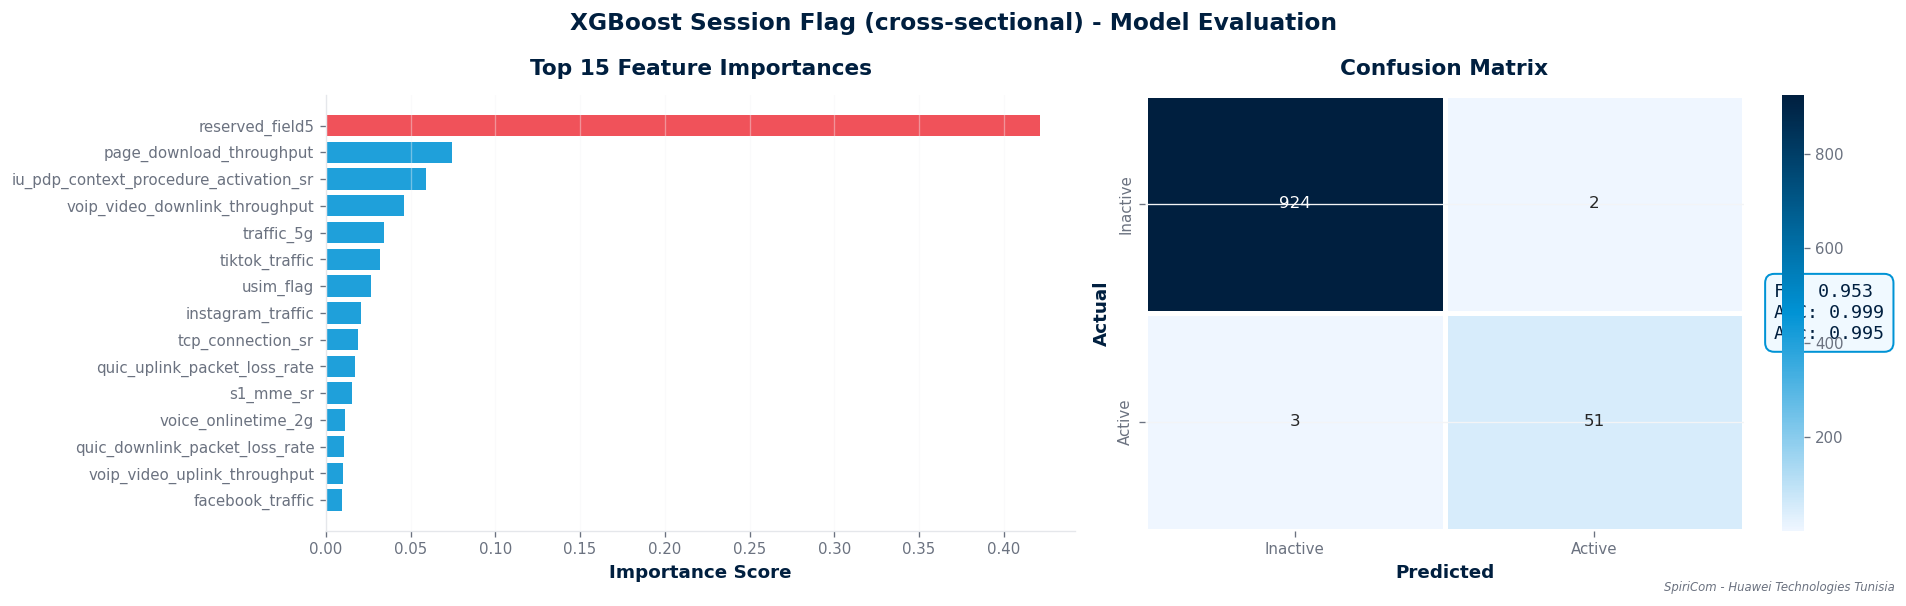

In [10]:
# ==============================================================
# A.3 Feature Importance + Confusion Matrix Visualization
# --------------------------------------------------------------
# This section provides interpretability and evaluation
# for the XGBoost session classification model.
# ==============================================================

if SESSION_TARGET is not None:

    # ----------------------------------------------------------
    # Create side-by-side evaluation plots
    # ----------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    fig.suptitle(
        f"XGBoost Session Flag ({SESSION_MODE}) - Model Evaluation",
        fontsize=14,
        fontweight="bold",
        color=HW["navy"]
    )

    # ==========================================================
    # 1. FEATURE IMPORTANCE
    # ==========================================================
    ax = axes[0]

    # Extract feature importance from trained XGBoost model
    fi = pd.Series(
        clf.feature_importances_,
        index=feat_cols_session
    )

    # Select top 15 most important features
    fi_top = fi.sort_values(ascending=True).tail(15)

    # Highlight most important feature
    colors_fi = [
        HW["red"] if v == fi_top.max() else HW["blue"]
        for v in fi_top
    ]

    ax.barh(
        fi_top.index,
        fi_top.values,
        color=colors_fi,
        alpha=0.88
    )

    ax.set_title("Top 15 Feature Importances", pad=12)
    ax.set_xlabel("Importance Score")

    ax.grid(axis="x", alpha=0.4)
    ax.grid(axis="y", visible=False)

    # ==========================================================
    # 2. CONFUSION MATRIX
    # ==========================================================
    ax2 = axes[1]

    cm = confusion_matrix(y_test_s, y_pred_s)

    # Custom Huawei-style color map
    cmap_cm = mcolors.LinearSegmentedColormap.from_list(
        "hw",
        ["#EFF6FF", "#0093D5", "#001F3F"]
    )

    sns.heatmap(
        cm,
        ax=ax2,
        cmap=cmap_cm,
        annot=True,
        fmt="d",
        xticklabels=["Inactive", "Active"],
        yticklabels=["Inactive", "Active"],
        linewidths=2,
        linecolor="white"
    )

    ax2.set_title("Confusion Matrix", pad=12)
    ax2.set_xlabel("Predicted")
    ax2.set_ylabel("Actual")

    # ----------------------------------------------------------
    # Display evaluation summary inside plot
    # ----------------------------------------------------------
    auc_txt = f"{auc_s:.3f}" if auc_s is not None else "n/a"

    ax2.text(
        1.05,
        0.5,
        f"F1: {f1_s:.3f}\nAUC: {auc_txt}\nAcc: {acc_s:.3f}",
        transform=ax2.transAxes,
        fontsize=11,
        va="center",
        fontfamily="monospace",
        color=HW["navy"],
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="#F0F9FF",
            edgecolor=HW["blue"],
            linewidth=1.2
        )
    )

    # ----------------------------------------------------------
    # Add watermark for Huawei-style visualization consistency
    # ----------------------------------------------------------
    add_watermark(fig)

    plt.tight_layout()

    # Save figure for thesis/report usage
    save_fig("figA1_session_flag_evaluation")

    plt.show()

## Section B — 5G Traffic: Prophet

In [11]:
# ==============================================================
# Section B — 5G Traffic Forecasting using Prophet
# --------------------------------------------------------------
# This module forecasts daily 5G traffic using Prophet with
# automatic selection between raw and log1p-transformed models.
# ==============================================================

if daily_5g is None:

    print("5G daily series unavailable - skipping Section B")

else:

    # ----------------------------------------------------------
    # Prepare Prophet input format
    # ----------------------------------------------------------
    train_p = train_5g.rename(
        columns={"traffic_5g": "y"}
    )[["ds", "y"]]

    test_p = test_5g.rename(
        columns={"traffic_5g": "y"}
    )[["ds", "y"]]

    true_p = test_p["y"].values

    print(
        f"Prophet train: {len(train_p)} points | "
        f"test: {len(test_p)} points"
    )

    # ----------------------------------------------------------
    # Coefficient of variation (traffic volatility)
    # ----------------------------------------------------------
    cv = train_p["y"].std() / max(train_p["y"].mean(), 1e-9)

    print(
        f"Series CV: {cv:.2f} "
        + ("(heavy-tailed - log likely beneficial)" if cv > 1 else "")
    )

    # ----------------------------------------------------------
    # Enable yearly seasonality if enough history exists
    # ----------------------------------------------------------
    use_yearly = (
        train_p["ds"].max() - train_p["ds"].min()
    ).days >= 365

    # ----------------------------------------------------------
    # Prophet training function
    # ----------------------------------------------------------
    def fit_prophet(frame, mode):

        m = Prophet(
            seasonality_mode=mode,
            yearly_seasonality=use_yearly,
            weekly_seasonality=True,
            daily_seasonality=False,
            changepoint_prior_scale=0.05,
            seasonality_prior_scale=5.0,
            interval_width=0.80
        )

        m.fit(frame)

        fut = m.make_future_dataframe(
            periods=len(test_p) + 30,
            freq="D"
        )

        return m, m.predict(fut)

    # ==========================================================
    # MODEL 1 — RAW SCALE
    # ==========================================================
    m_raw, fc_raw = fit_prophet(train_p, "multiplicative")

    al_raw = fc_raw[fc_raw["ds"].isin(test_p["ds"])]
    pred_raw = np.maximum(al_raw["yhat"].values, 0)

    mae_raw = mean_absolute_error(true_p, pred_raw)

    # ==========================================================
    # MODEL 2 — LOG TRANSFORMED
    # ==========================================================
    tp_log = train_p.copy()
    tp_log["y"] = np.log1p(tp_log["y"])

    m_log, fc_log = fit_prophet(tp_log, "additive")

    al_log = fc_log[fc_log["ds"].isin(test_p["ds"])]

    pred_log = np.maximum(
        np.expm1(al_log["yhat"].values),
        0
    )

    mae_log = mean_absolute_error(true_p, pred_log)

    # ----------------------------------------------------------
    # Model selection based on MAE
    # ----------------------------------------------------------
    PROPHET_LOG = mae_log < mae_raw

    print(
        f"Prophet raw MAE: {mae_raw:,.2f} | "
        f"log1p MAE: {mae_log:,.2f} -> "
        f"using {'log1p' if PROPHET_LOG else 'raw'} variant"
    )

    # ----------------------------------------------------------
    # Final model selection
    # ----------------------------------------------------------
    if PROPHET_LOG:

        m_prophet, forecast_p, aligned = m_log, fc_log, al_log.copy()

        for col in ["yhat", "yhat_lower", "yhat_upper"]:
            aligned[col] = np.expm1(aligned[col])

        pred_p = pred_log

    else:

        m_prophet, forecast_p, aligned = m_raw, fc_raw, al_raw.copy()

        pred_p = pred_raw

    # ----------------------------------------------------------
    # Final evaluation metrics
    # ----------------------------------------------------------
    prophet_mae = mean_absolute_error(true_p, pred_p)

    prophet_rmse = float(
        np.sqrt(mean_squared_error(true_p, pred_p))
    )

    prophet_mape = mape_score(true_p, pred_p)

    prophet_smape = smape_score(true_p, pred_p)

    print(f"Prophet - MAE  : {prophet_mae:,.2f}")
    print(f"Prophet - RMSE : {prophet_rmse:,.2f}")
    print(f"Prophet - MAPE : {prophet_mape:.2f}%")
    print(f"Prophet - sMAPE: {prophet_smape:.2f}%")

    # ----------------------------------------------------------
    # 30-day forecast output
    # ----------------------------------------------------------
    prophet_fc = forecast_p.tail(30)[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].copy()

    if PROPHET_LOG:
        for col in ["yhat", "yhat_lower", "yhat_upper"]:
            prophet_fc[col] = np.expm1(prophet_fc[col])

    prophet_fc["yhat"] = prophet_fc["yhat"].clip(lower=0)

Prophet train: 210 points | test: 53 points
Series CV: 2.58 (heavy-tailed - log likely beneficial)


09:13:40 - cmdstanpy - INFO - Chain [1] start processing
09:13:40 - cmdstanpy - INFO - Chain [1] done processing
09:13:40 - cmdstanpy - INFO - Chain [1] start processing
09:13:40 - cmdstanpy - INFO - Chain [1] done processing


Prophet raw MAE: 765,650,491.26 | log1p MAE: 709,063,413.14 -> using log1p variant
Prophet - MAE  : 709,063,413.14
Prophet - RMSE : 1,532,967,349.44
Prophet - MAPE : 2214.97%
Prophet - sMAPE: 156.09%


  Saved: data\outputs\figures\figB1_prophet_5g_forecast.png


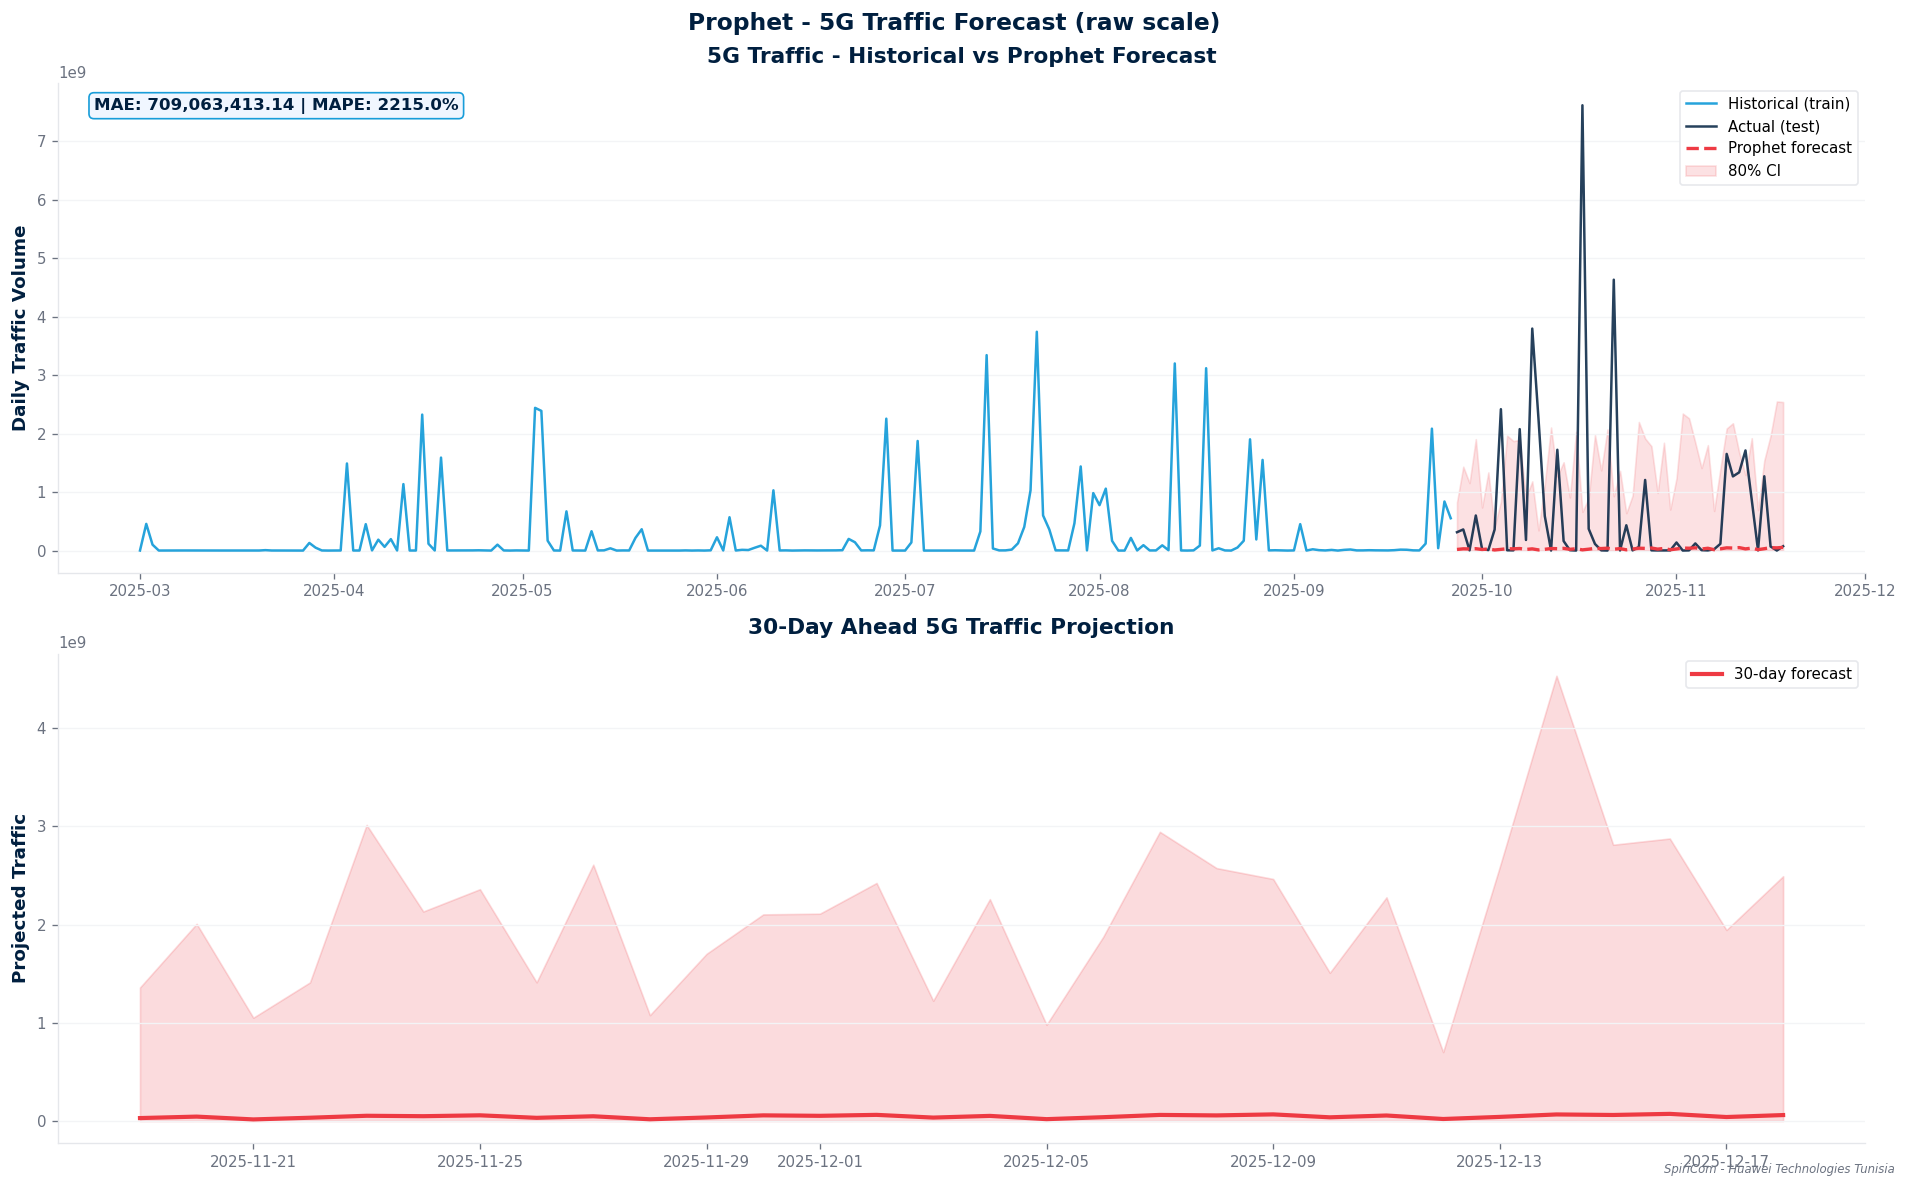

In [12]:
# ==============================================================
# B.1 Prophet Visualization — 5G Traffic Forecast
# --------------------------------------------------------------
# This section visualizes:
#   1. Historical vs predicted traffic (test period)
#   2. 30-day future traffic projection
# ==============================================================

if daily_5g is not None:

    # ----------------------------------------------------------
    # Create figure with two subplots
    # ----------------------------------------------------------
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    fig.suptitle(
        "Prophet - 5G Traffic Forecast (raw scale)",
        fontsize=14,
        fontweight="bold",
        color=HW["navy"]
    )

    # ==========================================================
    # PLOT 1 — Historical vs Forecast Comparison
    # ==========================================================
    ax = axes[0]

    # Training data (historical traffic)
    ax.plot(
        train_p["ds"],
        train_p["y"],
        color=HW["blue"],
        linewidth=1.5,
        label="Historical (train)",
        alpha=0.85
    )

    # Test data (ground truth)
    ax.plot(
        test_p["ds"],
        test_p["y"],
        color=HW["navy"],
        linewidth=1.5,
        label="Actual (test)",
        alpha=0.85
    )

    # Prophet predictions
    ax.plot(
        aligned["ds"],
        np.maximum(aligned["yhat"], 0),
        color=HW["red"],
        linewidth=2,
        linestyle="--",
        label="Prophet forecast"
    )

    # Confidence interval (80%)
    ax.fill_between(
        aligned["ds"],
        aligned["yhat_lower"].clip(lower=0),
        aligned["yhat_upper"],
        alpha=0.15,
        color=HW["red"],
        label="80% CI"
    )

    ax.set_title(
        "5G Traffic - Historical vs Prophet Forecast",
        pad=12
    )

    ax.set_ylabel("Daily Traffic Volume")
    ax.legend()

    # Error summary annotation
    ax.text(
        0.02,
        0.97,
        f"MAE: {prophet_mae:,.2f} | MAPE: {prophet_mape:.1f}%",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        color=HW["navy"],
        fontweight="bold",
        bbox=dict(
            boxstyle="round",
            facecolor="#EFF6FF",
            edgecolor=HW["blue"],
            alpha=0.9
        )
    )

    # ==========================================================
    # PLOT 2 — 30-Day Forecast
    # ==========================================================
    ax2 = axes[1]

    ax2.plot(
        prophet_fc["ds"],
        prophet_fc["yhat"],
        color=HW["red"],
        linewidth=2.5,
        label="30-day forecast"
    )

    ax2.fill_between(
        prophet_fc["ds"],
        prophet_fc["yhat_lower"].clip(lower=0),
        prophet_fc["yhat_upper"],
        alpha=0.18,
        color=HW["red"]
    )

    ax2.set_title(
        "30-Day Ahead 5G Traffic Projection",
        pad=12
    )

    ax2.set_ylabel("Projected Traffic")
    ax2.legend()

    # ----------------------------------------------------------
    # Branding + Export
    # ----------------------------------------------------------
    add_watermark(fig)

    plt.tight_layout()

    save_fig("figB1_prophet_5g_forecast")

    plt.show()

## Section C — 5G Traffic: ARIMA baseline
 

In [13]:
# ==============================================================
# Section C — 5G Traffic Forecasting (ARIMA Baseline)
# --------------------------------------------------------------
# This section implements a classical ARIMA model as a baseline
# for comparison against Prophet and ML-based forecasting.
# ==============================================================

if daily_5g is None or not PMDARIMA_OK:

    print("5G data or pmdarima unavailable - skipping Section C")

else:

    # ----------------------------------------------------------
    # Log transformation for variance stabilization
    # ----------------------------------------------------------
    train_log = np.log1p(train_p["y"].values)

    # ----------------------------------------------------------
    # Automatic ARIMA model selection
    # ----------------------------------------------------------
    m_arima = auto_arima(
        train_log,
        start_p=1,
        max_p=5,
        start_q=1,
        max_q=5,
        d=1,
        seasonal=False,
        stepwise=True,
        trace=False,
        error_action="ignore",
        suppress_warnings=True,
    )

    arima_order = m_arima.order
    print(f"Best ARIMA order: {arima_order}")

    # ----------------------------------------------------------
    # Forecasting
    # ----------------------------------------------------------
    pred_log = m_arima.predict(
        n_periods=len(test_p)
    )

    # Reverse log transformation
    pred_arima = np.maximum(
        np.expm1(pred_log),
        0
    )

    y_test_arima = test_p["y"].values

    # ----------------------------------------------------------
    # Evaluation metrics
    # ----------------------------------------------------------
    arima_mae = mean_absolute_error(
        y_test_arima,
        pred_arima
    )

    arima_rmse = float(
        np.sqrt(
            mean_squared_error(
                y_test_arima,
                pred_arima
            )
        )
    )

    arima_mape = mape_score(
        y_test_arima,
        pred_arima
    )

    arima_smape = smape_score(
        y_test_arima,
        pred_arima
    )

    # ----------------------------------------------------------
    # Results output
    # ----------------------------------------------------------
    print(f"ARIMA - MAE  : {arima_mae:,.2f}")
    print(f"ARIMA - RMSE : {arima_rmse:,.2f}")
    print(f"ARIMA - MAPE : {arima_mape:.2f}%")
    print(f"ARIMA - sMAPE: {arima_smape:.2f}%")

Best ARIMA order: (2, 1, 2)
ARIMA - MAE  : 711,412,445.05
ARIMA - RMSE : 1,538,013,911.91
ARIMA - MAPE : 856.49%
ARIMA - sMAPE: 158.11%


  Saved: data\outputs\figures\figC1_arima_5g_forecast.png


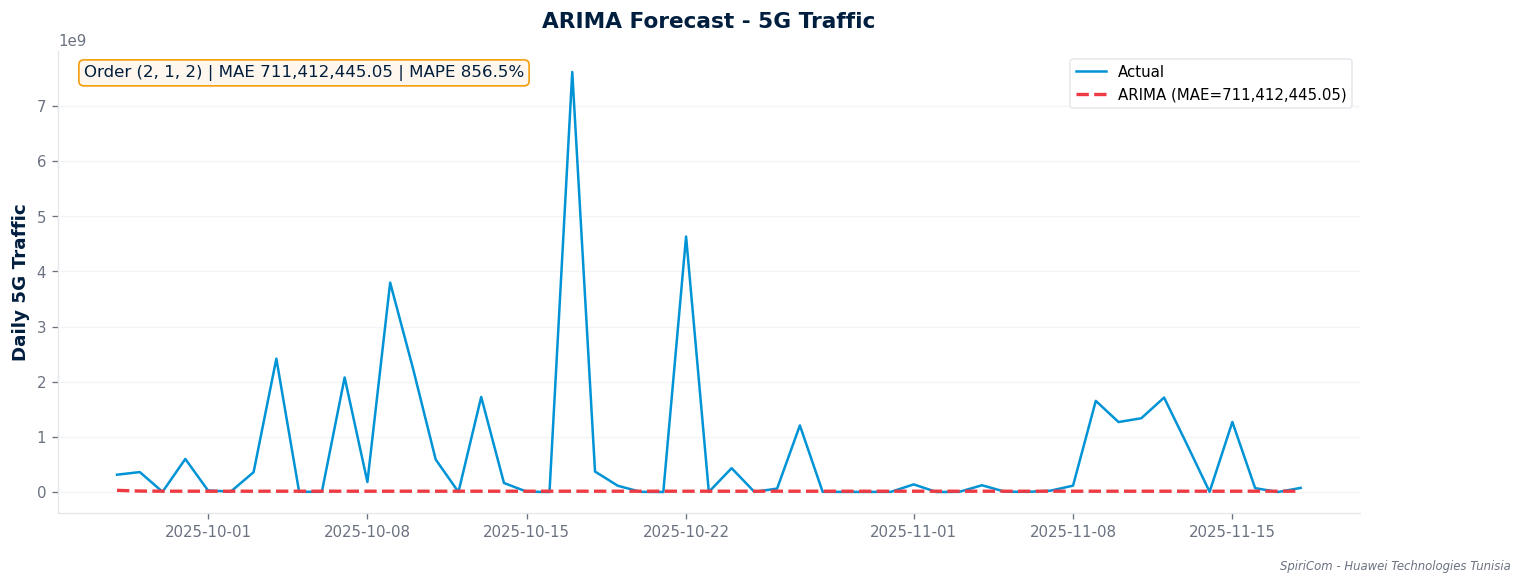

In [14]:
# ==============================================================
# C.1 ARIMA Forecast Visualization — 5G Traffic
# --------------------------------------------------------------
# This section visualizes ARIMA predictions vs actual traffic
# for the test period, enabling qualitative evaluation.
# ==============================================================

if daily_5g is not None and PMDARIMA_OK and arima_mae is not None:

    fig, ax = plt.subplots(figsize=(14, 5))

    # ----------------------------------------------------------
    # Actual traffic (ground truth)
    # ----------------------------------------------------------
    ax.plot(
        test_p["ds"].values,
        y_test_arima,
        color=HW["blue"],
        linewidth=1.5,
        label="Actual"
    )

    # ----------------------------------------------------------
    # ARIMA predictions
    # ----------------------------------------------------------
    ax.plot(
        test_p["ds"].values,
        pred_arima,
        color=HW["red"],
        linewidth=2,
        linestyle="--",
        label=f"ARIMA (MAE={arima_mae:,.2f})"
    )

    # ----------------------------------------------------------
    # Plot formatting
    # ----------------------------------------------------------
    ax.set_title("ARIMA Forecast - 5G Traffic", pad=14)
    ax.set_ylabel("Daily 5G Traffic")
    ax.legend()

    # ----------------------------------------------------------
    # Metrics annotation
    # ----------------------------------------------------------
    ax.text(
        0.02,
        0.97,
        f"Order {arima_order} | MAE {arima_mae:,.2f} | MAPE {arima_mape:.1f}%",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        color=HW["navy"],
        bbox=dict(
            boxstyle="round",
            facecolor="#FFF7ED",
            edgecolor=HW["amber"]
        )
    )

    # ----------------------------------------------------------
    # Branding + export
    # ----------------------------------------------------------
    add_watermark(fig)

    save_fig("figC1_arima_5g_forecast")

    plt.show()

## Section D — 5G Traffic: XGBoost with lag features

In [15]:
# ==============================================================
# Section D — 5G Traffic Forecasting (XGBoost Regression)
# --------------------------------------------------------------
# This model transforms time series forecasting into a
# supervised learning problem using lag + statistical features.
# ==============================================================

if daily_5g is None:

    print("5G data unavailable - skipping Section D")

else:

    # ----------------------------------------------------------
    # Feature engineering from time series
    # ----------------------------------------------------------
    ts_feat = daily_5g.copy().rename(
        columns={"traffic_5g": "y"}
    )

    # Lag features (autoregressive signals)
    for lag in [1, 2, 3, 7, 14]:
        ts_feat[f"lag_{lag}"] = ts_feat["y"].shift(lag)

    # Rolling statistics
    ts_feat["roll7_mean"] = ts_feat["y"].shift(1).rolling(7).mean()
    ts_feat["roll7_std"] = ts_feat["y"].shift(1).rolling(7).std()

    # Calendar features
    ts_feat["dow"] = ts_feat["ds"].dt.dayofweek
    ts_feat["month"] = ts_feat["ds"].dt.month
    ts_feat["week_num"] = ts_feat["ds"].dt.isocalendar().week.astype(int)

    # Remove missing values from lagging
    ts_feat = ts_feat.dropna().reset_index(drop=True)

    # ----------------------------------------------------------
    # Define feature set
    # ----------------------------------------------------------
    LAG_FEATURES = [
        c for c in ts_feat.columns
        if c not in ["ds", "y"]
    ]

    # ----------------------------------------------------------
    # Chronological train/test split
    # ----------------------------------------------------------
    split_ts = int(len(ts_feat) * SPLIT_RATIO)

    X_tr_r = ts_feat[LAG_FEATURES].iloc[:split_ts]
    y_tr_r = ts_feat["y"].iloc[:split_ts]

    X_te_r = ts_feat[LAG_FEATURES].iloc[split_ts:]
    y_te_r = ts_feat["y"].iloc[split_ts:]

    print(f"XGB regression features: {LAG_FEATURES}")
    print(f"Train: {len(X_tr_r)}, Test: {len(X_te_r)}")

    # ----------------------------------------------------------
    # XGBoost regression model
    # ----------------------------------------------------------
    reg = xgb.XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

    # Train model
    reg.fit(
        X_tr_r,
        y_tr_r,
        eval_set=[(X_te_r, y_te_r)],
        verbose=False
    )

    # ----------------------------------------------------------
    # Predictions (clipped to valid traffic range)
    # ----------------------------------------------------------
    pred_xgb_r = np.maximum(
        reg.predict(X_te_r),
        0
    )

    # ----------------------------------------------------------
    # Evaluation metrics
    # ----------------------------------------------------------
    xgb_reg_mae = mean_absolute_error(y_te_r, pred_xgb_r)

    xgb_reg_rmse = float(
        np.sqrt(
            mean_squared_error(y_te_r, pred_xgb_r)
        )
    )

    xgb_reg_r2 = r2_score(y_te_r, pred_xgb_r)

    xgb_reg_mape = mape_score(y_te_r.values, pred_xgb_r)

    xgb_reg_smape = smape_score(y_te_r.values, pred_xgb_r)

    # ----------------------------------------------------------
    # Results
    # ----------------------------------------------------------
    print(f"XGBoost Regression - MAE  : {xgb_reg_mae:,.2f}")
    print(f"XGBoost Regression - RMSE : {xgb_reg_rmse:,.2f}")
    print(f"XGBoost Regression - R2   : {xgb_reg_r2:.4f}")
    print(f"XGBoost Regression - MAPE : {xgb_reg_mape:.2f}%")
    print(f"XGBoost Regression - sMAPE: {xgb_reg_smape:.2f}%")

XGB regression features: ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'roll7_mean', 'roll7_std', 'dow', 'month', 'week_num']
Train: 199, Test: 50
XGBoost Regression - MAE  : 859,458,848.78
XGBoost Regression - RMSE : 1,523,812,314.83
XGBoost Regression - R2   : -0.1802
XGBoost Regression - MAPE : 26227.71%
XGBoost Regression - sMAPE: 149.74%


  Saved: data\outputs\figures\figD1_xgboost_5g_regression.png


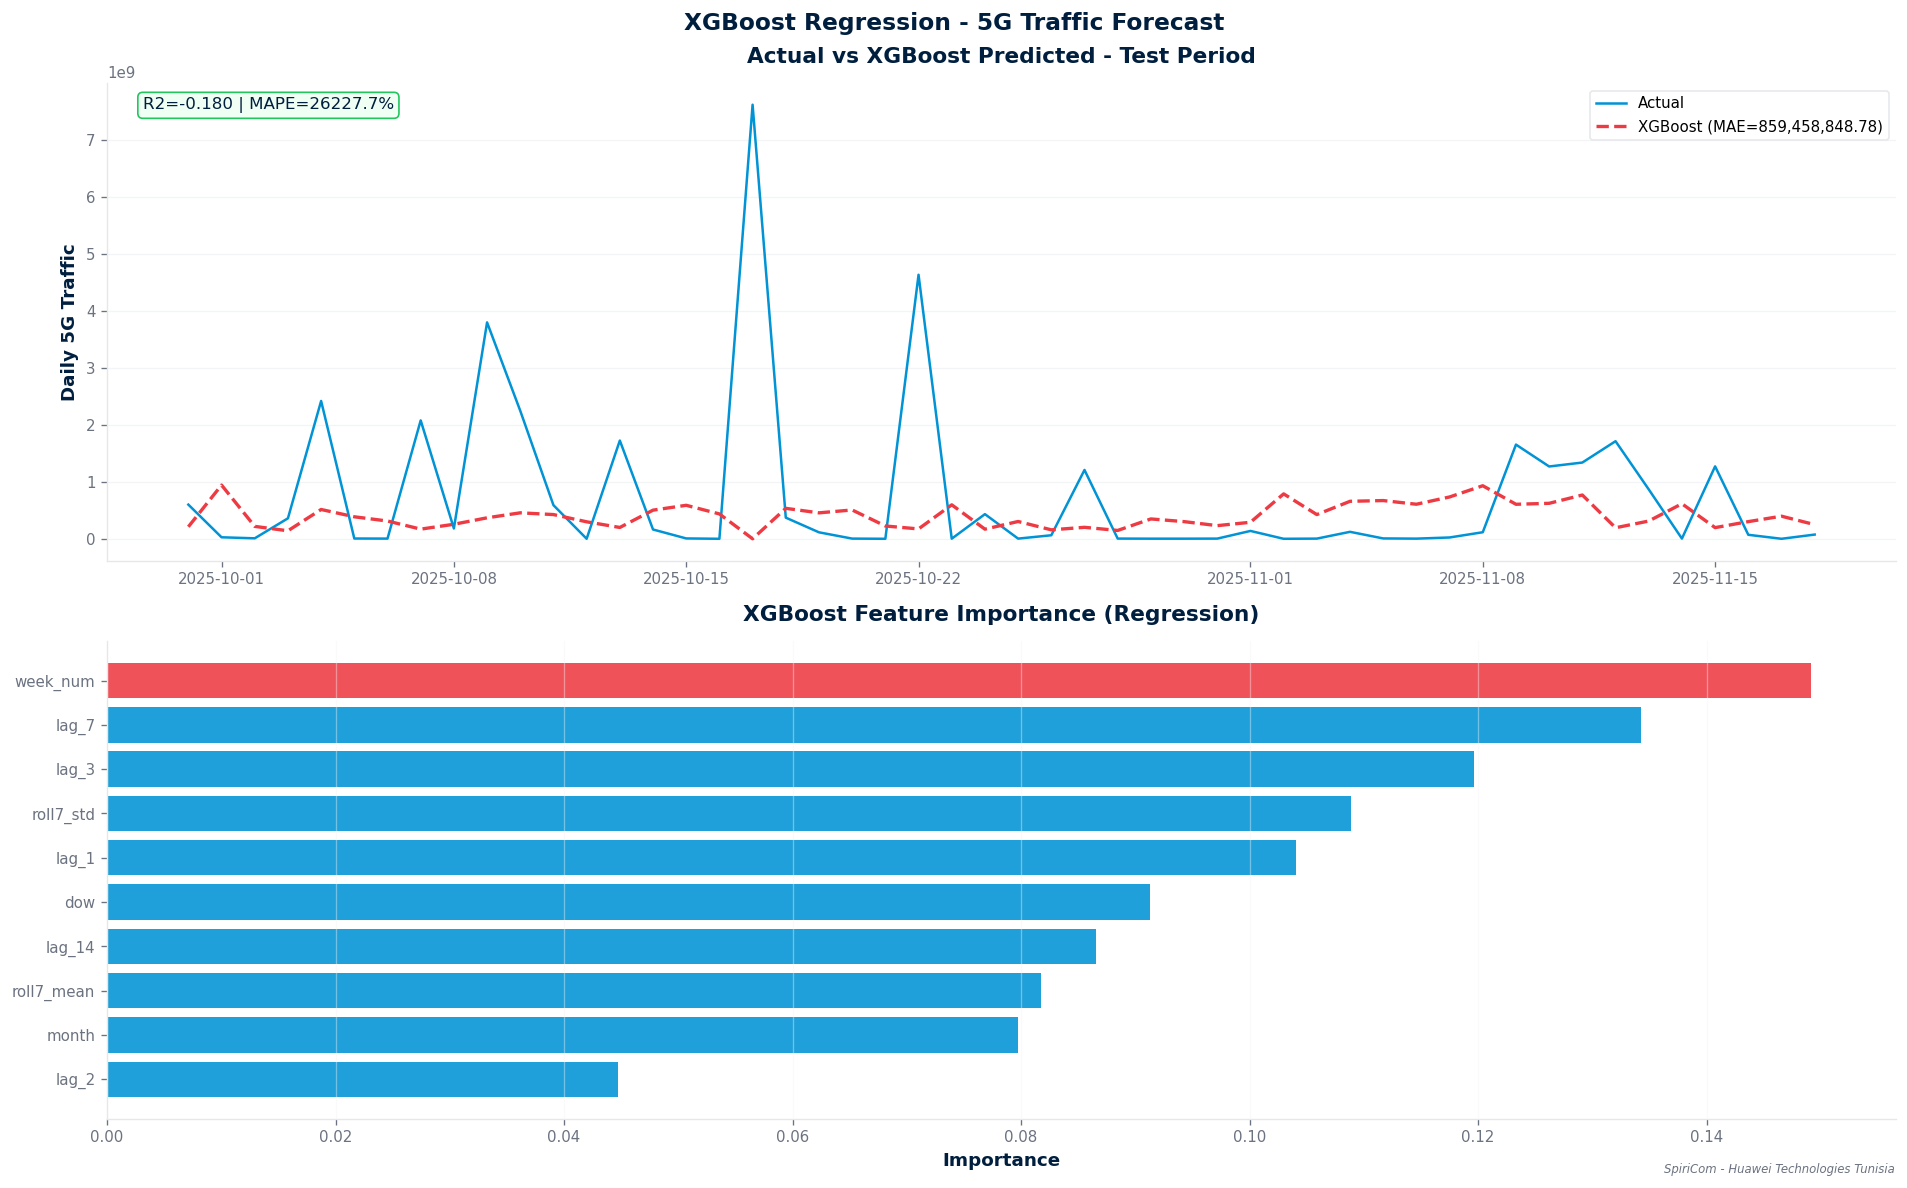

In [16]:
# ==============================================================
# D.1 XGBoost Regression Visualization — 5G Traffic Forecast
# --------------------------------------------------------------
# This section visualizes:
#   1. Actual vs predicted traffic (test period)
#   2. Feature importance of lag-based regression model
# ==============================================================

if daily_5g is not None and xgb_reg_mae is not None:

    # ----------------------------------------------------------
    # Extract test period dates
    # ----------------------------------------------------------
    dates_te = ts_feat["ds"].iloc[split_ts:].values

    # ----------------------------------------------------------
    # Create figure with two subplots
    # ----------------------------------------------------------
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    fig.suptitle(
        "XGBoost Regression - 5G Traffic Forecast",
        fontsize=14,
        fontweight="bold",
        color=HW["navy"]
    )

    # ==========================================================
    # PLOT 1 — Actual vs Predicted Traffic
    # ==========================================================
    ax = axes[0]

    # Ground truth
    ax.plot(
        dates_te,
        y_te_r.values,
        color=HW["blue"],
        lw=1.5,
        label="Actual"
    )

    # XGBoost predictions
    ax.plot(
        dates_te,
        pred_xgb_r,
        color=HW["red"],
        lw=2.0,
        ls="--",
        label=f"XGBoost (MAE={xgb_reg_mae:,.2f})"
    )

    ax.set_title(
        "Actual vs XGBoost Predicted - Test Period",
        pad=12
    )

    ax.set_ylabel("Daily 5G Traffic")
    ax.legend()

    # Metrics annotation
    ax.text(
        0.02,
        0.97,
        f"R2={xgb_reg_r2:.3f} | MAPE={xgb_reg_mape:.1f}%",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        color=HW["navy"],
        bbox=dict(
            boxstyle="round",
            facecolor="#F0FFF4",
            edgecolor=HW["green"]
        )
    )

    # ==========================================================
    # PLOT 2 — Feature Importance
    # ==========================================================
    ax2 = axes[1]

    # Compute feature importance
    fi_reg = pd.Series(
        reg.feature_importances_,
        index=LAG_FEATURES
    ).sort_values(ascending=True)

    # Highlight most important feature
    bar_c = [
        HW["red"] if v == fi_reg.max() else HW["blue"]
        for v in fi_reg
    ]

    ax2.barh(
        fi_reg.index,
        fi_reg.values,
        color=bar_c,
        alpha=0.88
    )

    ax2.set_title(
        "XGBoost Feature Importance (Regression)",
        pad=12
    )

    ax2.set_xlabel("Importance")

    ax2.grid(axis="x", alpha=0.4)
    ax2.grid(axis="y", visible=False)

    # ----------------------------------------------------------
    # Branding + export
    # ----------------------------------------------------------
    add_watermark(fig)

    plt.tight_layout()

    save_fig("figD1_xgboost_5g_regression")

    plt.show()

## Section E — Brand Traffic Forecast


In [17]:
brand_scores = []  # List to store evaluation metrics for each brand (MAE, MAPE, model selection, etc.)
brand_forecasts_list = []  # List to store final 30-day forecasts for all brands

# ------------------------------------------------------------
# Seasonal Naive Forecast Function (Baseline Model)
# ------------------------------------------------------------
def seasonal_naive(train_y, test_len, season=7):
    # Extract the last seasonal window (weekly pattern)
    last = train_y[-season:]  
    
    # Repeat the last 7 values enough times to cover forecast horizon
    reps = int(np.ceil(test_len / season))
    
    # Return repeated seasonal pattern trimmed to exact length
    return np.tile(last, reps)[:test_len]


# ------------------------------------------------------------
# Check if brand-level dataset exists
# ------------------------------------------------------------
if brand_daily is None:
    print('Brand data unavailable - skipping Section E')

else:
    # Extract all unique brands present in dataset
    brands = brand_daily['brand'].unique()
    
    print(f'Forecasting {len(brands)} brands: {brands.tolist()}')

    # --------------------------------------------------------
    # Loop over each brand independently (multi-series forecasting)
    # --------------------------------------------------------
    for brand in brands:

        # Filter dataset for current brand and sort by time
        bdf = (
            brand_daily[brand_daily['brand'] == brand]
            .sort_values('ds')
            .reset_index(drop=True)
        )

        # Skip brands with insufficient data (< 14 days)
        if len(bdf) < 14:
            print(f'  {brand}: too few points ({len(bdf)}) - skipped')
            continue

        # ----------------------------------------------------
        # Chronological train/test split (time series split)
        # ----------------------------------------------------
        nb_split = int(len(bdf) * SPLIT_RATIO)

        # Training set (rename target to 'y' for Prophet compatibility)
        b_train = (
            bdf.iloc[:nb_split]
            .rename(columns={'traffic': 'y'})[['ds', 'y']]
        )

        # Test set
        b_test = (
            bdf.iloc[nb_split:]
            .rename(columns={'traffic': 'y'})[['ds', 'y']]
        )

        # ----------------------------------------------------
        # Baseline Model: Seasonal Naive Forecast
        # ----------------------------------------------------
        snaive_pred = seasonal_naive(
            b_train['y'].values,
            len(b_test)
        )

        # Evaluate baseline performance
        snaive_mae = mean_absolute_error(b_test['y'].values, snaive_pred)
        snaive_mape = mape_score(b_test['y'].values, snaive_pred)

        # ----------------------------------------------------
        # Prophet Model Initialization
        # ----------------------------------------------------
        prophet_b_mae = None  # Will store Prophet MAE if successful

        try:
            # Define Prophet model with telecom-friendly settings
            mp = Prophet(
                seasonality_mode='multiplicative',  # traffic grows proportionally
                weekly_seasonality=True,            # weekly cycles in usage
                yearly_seasonality=False,           # insufficient yearly data
                changepoint_prior_scale=0.1,        # controls trend flexibility
                interval_width=0.80                 # 80% uncertainty interval
            )

            # Fit model on training data
            mp.fit(b_train)

            # Create future dataframe (test period + 30-day forecast horizon)
            future_b = mp.make_future_dataframe(
                periods=len(b_test) + 30,
                freq='D'
            )

            # Generate forecast
            fc_b = mp.predict(future_b)

            # Extract predictions aligned with test period
            preds_b = (
                fc_b[fc_b['ds'].isin(b_test['ds'])]['yhat']
                .clip(lower=0)   # traffic cannot be negative
                .values
            )

            # Evaluate Prophet only if alignment is correct
            if len(preds_b) == len(b_test):
                prophet_b_mae = mean_absolute_error(b_test['y'].values, preds_b)
                prophet_b_mape = mape_score(b_test['y'].values, preds_b)

        except Exception as e:
            # Handle model failure safely (small data, convergence issues, etc.)
            print(f'  {brand}: Prophet failed ({e})')

        # ----------------------------------------------------
        # Model Selection Logic (Winner-Takes-All)
        # ----------------------------------------------------
        if prophet_b_mae is not None and prophet_b_mae <= snaive_mae:
            winner, w_mae, w_mape = 'prophet', prophet_b_mae, prophet_b_mape
        else:
            winner, w_mae, w_mape = 'seasonal_naive', snaive_mae, snaive_mape

        # ----------------------------------------------------
        # 30-Day Forecast Generation
        # ----------------------------------------------------
        if winner == 'prophet':
            # Use Prophet forecast directly
            future_30 = fc_b.tail(30)[['ds', 'yhat']].copy()
            future_30.rename(columns={'yhat': 'forecast'}, inplace=True)

        else:
            # Use seasonal repetition of last weekly pattern
            fut_dates = pd.date_range(
                bdf['ds'].max() + pd.Timedelta(days=1),
                periods=30,
                freq='D'
            )

            future_30 = pd.DataFrame({
                'ds': fut_dates,
                'forecast': seasonal_naive(
                    bdf['traffic'].values,
                    30
                ),
            })

        # ----------------------------------------------------
        # Post-processing (data cleaning)
        # ----------------------------------------------------
        future_30['forecast'] = future_30['forecast'].clip(lower=0)  # no negative traffic
        future_30['brand'] = brand
        future_30['target'] = BRAND_TARGET or 'traffic'
        future_30['model'] = winner

        # Store forecast results
        brand_forecasts_list.append(future_30)

        # ----------------------------------------------------
        # Store evaluation metrics for reporting
        # ----------------------------------------------------
        brand_scores.append({
            'brand': brand,
            'model': winner,
            'mae': round(float(w_mae), 3),
            'mape': round(float(w_mape), 2),
            'prophet_mae': round(float(prophet_b_mae), 3)
                if prophet_b_mae is not None else None,
            'snaive_mae': round(float(snaive_mae), 3),
            'n_test': len(b_test),
        })

        # ----------------------------------------------------
        # Console logging for monitoring
        # ----------------------------------------------------
        pm = f'{prophet_b_mae:,.2f}' if prophet_b_mae is not None else 'failed'

        print(
            f'  {brand:<20s} '
            f'prophet MAE={pm}  '
            f'snaive MAE={snaive_mae:,.2f}  '
            f'-> winner: {winner}'
        )

09:13:53 - cmdstanpy - INFO - Chain [1] start processing
09:13:53 - cmdstanpy - INFO - Chain [1] done processing


Forecasting 5 brands: ['APPLE', 'INFINIX', 'SAMSUNG', 'XIAOMI', 'OPPO']


09:13:53 - cmdstanpy - INFO - Chain [1] start processing


  APPLE                prophet MAE=546,845,847.57  snaive MAE=578,064,951.86  -> winner: prophet


09:13:53 - cmdstanpy - INFO - Chain [1] done processing
09:13:54 - cmdstanpy - INFO - Chain [1] start processing


  INFINIX              prophet MAE=19,301,355.45  snaive MAE=13,278,181.69  -> winner: seasonal_naive


09:13:54 - cmdstanpy - INFO - Chain [1] done processing
09:13:54 - cmdstanpy - INFO - Chain [1] start processing


  SAMSUNG              prophet MAE=394,550,113.52  snaive MAE=308,828,470.47  -> winner: seasonal_naive


09:13:54 - cmdstanpy - INFO - Chain [1] done processing
09:13:54 - cmdstanpy - INFO - Chain [1] start processing
09:13:55 - cmdstanpy - INFO - Chain [1] done processing


  XIAOMI               prophet MAE=36,066,678.55  snaive MAE=36,380,338.32  -> winner: prophet
  OPPO                 prophet MAE=66,073,458.55  snaive MAE=133,634,937.07  -> winner: prophet



Brand Forecast Scores:
  brand          model            mae       mape    prophet_mae     snaive_mae  n_test
INFINIX seasonal_naive  13278181.6940   157.5600  19301355.4550  13278181.6940      36
 XIAOMI        prophet  36066678.5530   100.0000  36066678.5530  36380338.3160      38
   OPPO        prophet  66073458.5490 12162.6300  66073458.5490 133634937.0670      30
SAMSUNG seasonal_naive 308828470.4650  8021.5200 394550113.5160 308828470.4650      43
  APPLE        prophet 546845847.5670 35735.0300 546845847.5670 578064951.8570      28
  Saved: data\outputs\figures\figE2_brand_mae_comparison.png


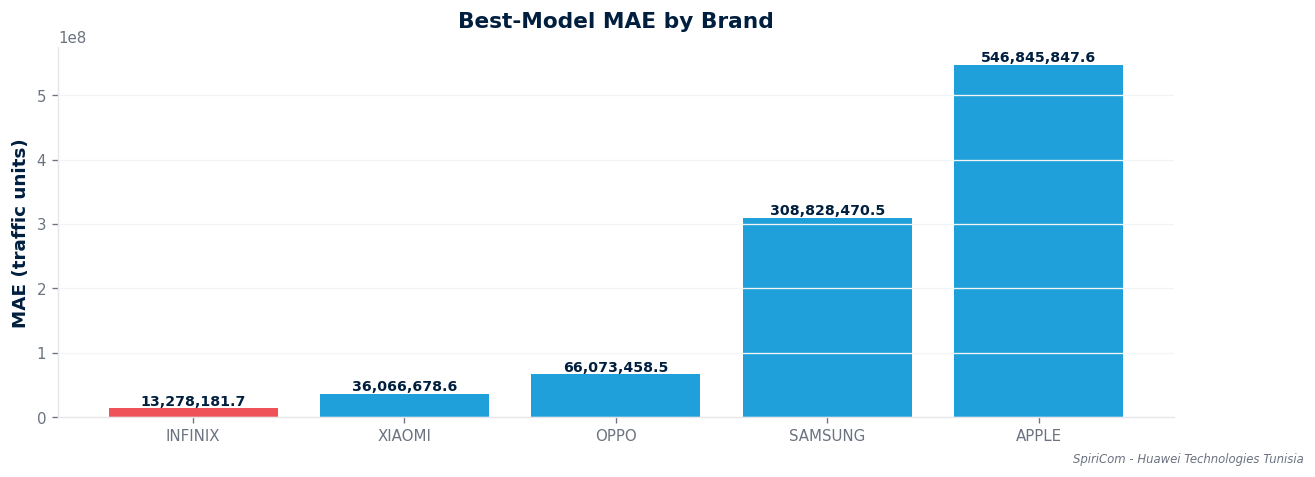

In [18]:
# ------------------------------------------------------------
# Brand Forecast Visualization + Performance Analysis
# ------------------------------------------------------------
# This section aggregates all per-brand forecasts, visualizes them,
# and evaluates model performance across brands.
# ------------------------------------------------------------

from IPython.display import display  # Used to render Plotly figure in Jupyter notebook

# ------------------------------------------------------------
# Check availability of brand-level forecasts
# ------------------------------------------------------------
if brand_daily is not None and len(brand_forecasts_list) > 0:

    # --------------------------------------------------------
    # Concatenate all brand forecasts into a single DataFrame
    # --------------------------------------------------------
    # Each row represents a predicted value for a given brand and date
    all_fc_brands = pd.concat(brand_forecasts_list, ignore_index=True)

    # --------------------------------------------------------
    # Interactive Plot: 30-Day Forecast per Brand
    # --------------------------------------------------------
    fig = px.line(
        all_fc_brands,
        x='ds',                      # time axis (date)
        y='forecast',                # predicted traffic values
        color='brand',              # one curve per brand
        title='30-Day Traffic Forecast by Device Brand',
        labels={
            'ds': 'Date',
            'forecast': 'Forecast Traffic',
            'brand': 'Brand'
        },
        color_discrete_sequence=PALETTE  # custom color palette for consistency
    )

    # Apply global layout configuration (theme, margins, fonts, etc.)
    fig.update_layout(**PLOTLY_LAYOUT)

    # Save interactive chart as HTML file for reporting/dashboard use
    fig.write_html(str(FIG_DIR / 'figE1_brand_forecast.html'))

    # Display interactive chart in notebook
    display(fig)

    # --------------------------------------------------------
    # Performance Summary Table (per brand)
    # --------------------------------------------------------
    bs_df = pd.DataFrame(brand_scores).sort_values('mae')

    print('\nBrand Forecast Scores:')
    print(bs_df.to_string(index=False))

    # --------------------------------------------------------
    # Bar Plot: MAE comparison across brands
    # --------------------------------------------------------
    fig2, ax = plt.subplots(figsize=(12, 4))

    # Highlight best-performing brand (minimum MAE)
    colors_b = [
        HW['red'] if row.mae == bs_df['mae'].min() else HW['blue']
        for row in bs_df.itertuples()
    ]

    ax.bar(
        bs_df['brand'],
        bs_df['mae'],
        color=colors_b,
        alpha=0.88
    )

    ax.set_title('Best-Model MAE by Brand', pad=12)
    ax.set_ylabel('MAE (traffic units)')

    # Annotate each bar with MAE value
    for i, row in enumerate(bs_df.itertuples()):
        ax.text(
            i,
            row.mae + bs_df['mae'].max() * 0.01,
            f'{row.mae:,.1f}',
            ha='center',
            fontsize=8.5,
            color=HW['navy'],
            fontweight='bold'
        )

    # Add branding watermark for report consistency
    add_watermark(fig2)

    # Save figure for thesis/report
    save_fig('figE2_brand_mae_comparison')

    # Display final plot
    plt.show()

## Section 9 — Model Comparison

In [19]:
# ------------------------------------------------------------
# Section 9 — Model Comparison (Global Evaluation Summary)
# ------------------------------------------------------------
# This section consolidates performance metrics from all models
# (classification + forecasting) into a single comparison table.
# It is used to evaluate whether each model meets its predefined
# performance targets in the SpiriCom pipeline.
# ------------------------------------------------------------

rows = []  # Container for all model evaluation results

# ------------------------------------------------------------
# Session Flag Model (XGBoost Classification)
# ------------------------------------------------------------
# F1-score evaluation (handles class imbalance: active vs inactive sessions)
if f1_s is not None:
    rows.append({
        'model': 'XGBoost',
        'target': 'session_flag',
        'metric': 'F1',
        'value': round(f1_s, 4),
        # Target threshold defined by business requirement (> 0.72)
        'pass': f1_s > 0.72
    })

# ROC-AUC evaluation (measures ranking quality of predictions)
if auc_s is not None:
    rows.append({
        'model': 'XGBoost',
        'target': 'session_flag',
        'metric': 'AUC-ROC',
        'value': round(auc_s, 4),
        # Strong discrimination threshold (> 0.85)
        'pass': auc_s > 0.85
    })

# ------------------------------------------------------------
# Prophet Model (5G Traffic Forecasting)
# ------------------------------------------------------------
if prophet_mae is not None:
    rows.append({
        'model': 'Prophet',
        'target': 'traffic_5G',
        'metric': 'MAE',
        'value': round(prophet_mae, 2),
        # MAE is always valid; used for comparison only
        'pass': True
    })

    rows.append({
        'model': 'Prophet',
        'target': 'traffic_5G',
        'metric': 'MAPE',
        'value': round(prophet_mape, 2),
        # Business constraint: error should be < 20%
        'pass': prophet_mape < 20
    })

# ------------------------------------------------------------
# ARIMA Model (Statistical Baseline Forecasting)
# ------------------------------------------------------------
if arima_mae is not None:
    rows.append({
        'model': 'ARIMA',
        'target': 'traffic_5G',
        'metric': 'MAE',
        'value': round(arima_mae, 2),
        'pass': True
    })

    rows.append({
        'model': 'ARIMA',
        'target': 'traffic_5G',
        'metric': 'MAPE',
        'value': round(arima_mape, 2),
        'pass': arima_mape < 20
    })

# ------------------------------------------------------------
# XGBoost Regression Model (ML-based Forecasting)
# ------------------------------------------------------------
if xgb_reg_mae is not None:
    rows.append({
        'model': 'XGBoost',
        'target': 'traffic_5G',
        'metric': 'MAE',
        'value': round(xgb_reg_mae, 2),
        'pass': True
    })

    rows.append({
        'model': 'XGBoost',
        'target': 'traffic_5G',
        'metric': 'MAPE',
        'value': round(xgb_reg_mape, 2),
        'pass': xgb_reg_mape < 20
    })

    rows.append({
        'model': 'XGBoost',
        'target': 'traffic_5G',
        'metric': 'R2',
        'value': round(xgb_reg_r2, 4),
        # Good explanatory power threshold
        'pass': xgb_reg_r2 > 0.7
    })

# ------------------------------------------------------------
# Build final comparison table
# ------------------------------------------------------------
compare_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Display results if available
# ------------------------------------------------------------
if len(compare_df) > 0:

    print('=== MODEL COMPARISON ===')

    # Full performance table (all models + metrics)
    print(compare_df.to_string(index=False))

    # Overall success indicator:
    # True only if ALL metrics satisfy their thresholds
    print(f'\nPassed all targets: {bool(compare_df["pass"].all())}')

=== MODEL COMPARISON ===
  model       target  metric          value  pass
XGBoost session_flag      F1         0.9533  True
XGBoost session_flag AUC-ROC         0.9994  True
Prophet   traffic_5G     MAE 709063413.1400  True
Prophet   traffic_5G    MAPE      2214.9700 False
  ARIMA   traffic_5G     MAE 711412445.0500  True
  ARIMA   traffic_5G    MAPE       856.4900 False
XGBoost   traffic_5G     MAE 859458848.7800  True
XGBoost   traffic_5G    MAPE     26227.7100 False
XGBoost   traffic_5G      R2        -0.1802 False

Passed all targets: False


  Saved: data\outputs\figures\fig09_model_comparison_mae.png


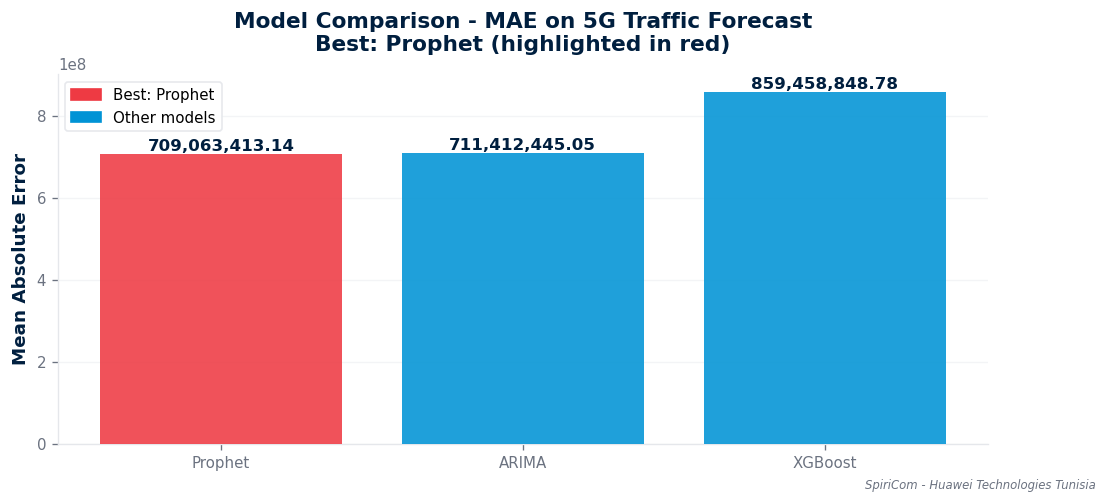

Best model for 5G traffic: Prophet


In [20]:
# ------------------------------------------------------------
# Model Comparison Visualization — MAE (5G Traffic Forecast)
# ------------------------------------------------------------
# This section identifies the best-performing forecasting model
# based on MAE (Mean Absolute Error) for the 5G traffic target,
# and visualizes a comparative bar chart.
#
# MAE is used as the primary metric because:
# - it is scale-dependent and interpretable in traffic units
# - it penalizes absolute deviations equally
# - it is robust for comparing forecasting models on same dataset
# ------------------------------------------------------------

# Ensure comparison table exists and 5G dataset was processed
if len(compare_df) > 0 and daily_5g is not None:

    # --------------------------------------------------------
    # Filter only MAE metrics for 5G traffic forecasting models
    # --------------------------------------------------------
    mae_rows = compare_df[
        (compare_df['target'] == 'traffic_5G') &
        (compare_df['metric'] == 'MAE')
    ].copy()

    # Proceed only if MAE results exist
    if len(mae_rows) > 0:

        # ----------------------------------------------------
        # Identify best model (lowest MAE = best performance)
        # ----------------------------------------------------
        best_model = mae_rows.loc[
            mae_rows['value'].idxmin(),
            'model'
        ]

        # ----------------------------------------------------
        # Visualization: MAE comparison across models
        # ----------------------------------------------------
        fig, ax = plt.subplots(figsize=(10, 4))

        # Highlight best model in red, others in blue
        colors_m = [
            HW['red'] if m == best_model else HW['blue']
            for m in mae_rows['model']
        ]

        # Bar chart of MAE values
        bars = ax.bar(
            mae_rows['model'],
            mae_rows['value'],
            color=colors_m,
            alpha=0.88,
            zorder=3
        )

        # ----------------------------------------------------
        # Annotate bars with numeric MAE values
        # ----------------------------------------------------
        for bar, v in zip(bars, mae_rows['value']):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f'{v:,.2f}',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
                color=HW['navy']
            )

        # ----------------------------------------------------
        # Chart formatting
        # ----------------------------------------------------
        ax.set_title(
            'Model Comparison - MAE on 5G Traffic Forecast\n'
            f'Best: {best_model} (highlighted in red)',
            pad=14
        )

        ax.set_ylabel('Mean Absolute Error')

        # Legend explaining color encoding
        ax.legend(handles=[
            mpatches.Patch(color=HW['red'], label=f'Best: {best_model}'),
            mpatches.Patch(color=HW['blue'], label='Other models'),
        ])

        # Add watermark for report branding consistency
        add_watermark(fig)

        # Save figure for thesis/report documentation
        save_fig('fig09_model_comparison_mae')

        # Display final chart
        plt.show()

        # ----------------------------------------------------
        # Print best model summary (decision output)
        # ----------------------------------------------------
        print(f'Best model for 5G traffic: {best_model}')

## Section 10 — Save Artifacts & Models

In [21]:
# ------------------------------------------------------------
# Section 10.1 — Saving Prediction Scores (Parquet Output)
# ------------------------------------------------------------
# This section builds a unified performance summary table that
# aggregates:
#   - global model performance (ALL traffic_5G models)
#   - per-brand forecasting performance
#
# The final output is stored in a Parquet file for:
#   - fast loading in analytics pipelines
#   - integration with BI tools
#   - reproducible reporting in the PFE system
# ------------------------------------------------------------

score_rows = []  # Container for all scoring records

# ------------------------------------------------------------
# Global evaluation row (ALL region / full dataset)
# ------------------------------------------------------------
base_row = {
    'region': 'ALL',            # global aggregation level
    'target': 'traffic_5G'      # forecasting target
}

# Add Prophet metrics if available
if prophet_mae is not None:
    base_row.update({
        'prophet_mae': prophet_mae,
        'prophet_mape': prophet_mape
    })

# Add ARIMA metrics if available
if arima_mae is not None:
    base_row.update({
        'arima_mae': arima_mae,
        'arima_mape': arima_mape
    })

# Add XGBoost regression metrics if available
if xgb_reg_mae is not None:
    base_row.update({
        'xgboost_mae': xgb_reg_mae,
        'xgboost_mape': xgb_reg_mape,
        'xgboost_r2': xgb_reg_r2
    })

# ------------------------------------------------------------
# Determine best global model based on MAE
# ------------------------------------------------------------
# Extract MAE values for each model
mae_by_model = {
    k.replace('_mae', ''): v
    for k, v in base_row.items()
    if k.endswith('_mae')
}

# Select model with minimum MAE (best predictive accuracy)
if mae_by_model:
    base_row['winner'] = min(mae_by_model, key=mae_by_model.get)

# Add global row to final scoring table
score_rows.append(base_row)

# ------------------------------------------------------------
# Append per-brand evaluation results
# ------------------------------------------------------------
for bs in brand_scores:
    score_rows.append({
        'region': bs['brand'],  # each brand treated as a "region"
        'target': BRAND_TARGET or 'traffic',

        # Prophet performance per brand (if available)
        'prophet_mae': bs.get('prophet_mae'),

        # Seasonal naive baseline performance
        'snaive_mae': bs.get('snaive_mae'),

        # Best achieved performance for that brand
        'best_mae': bs['mae'],
        'best_mape': bs['mape'],

        # Model selected as best for this brand
        'winner': bs['model'],
    })

# ------------------------------------------------------------
# Convert to DataFrame for structured storage
# ------------------------------------------------------------
scores_df = pd.DataFrame(score_rows)

# ------------------------------------------------------------
# Save as Parquet file (efficient columnar format)
# ------------------------------------------------------------
scores_path = MODEL_DIR / 'prediction_scores.parquet'
scores_df.to_parquet(scores_path, index=False)

# ------------------------------------------------------------
# Output confirmation + preview
# ------------------------------------------------------------
print(f'Saved: {scores_path}')
print(scores_df.to_string(index=False))

Saved: models\prediction\prediction_scores.parquet
 region     target    prophet_mae  prophet_mape      arima_mae  arima_mape    xgboost_mae  xgboost_mape  xgboost_r2         winner     snaive_mae       best_mae  best_mape
    ALL traffic_5G 709063413.1445     2214.9712 711412445.0518    856.4871 859458848.7800    26227.7109     -0.1802        prophet            NaN            NaN        NaN
  APPLE traffic_5g 546845847.5670           NaN            NaN         NaN            NaN           NaN         NaN        prophet 578064951.8570 546845847.5670 35735.0300
INFINIX traffic_5g  19301355.4550           NaN            NaN         NaN            NaN           NaN         NaN seasonal_naive  13278181.6940  13278181.6940   157.5600
SAMSUNG traffic_5g 394550113.5160           NaN            NaN         NaN            NaN           NaN         NaN seasonal_naive 308828470.4650 308828470.4650  8021.5200
 XIAOMI traffic_5g  36066678.5530           NaN            NaN         NaN            NaN

In [22]:
# ------------------------------------------------------------
# Section 10.2 — Saving Forecast Outputs (Parquet File)
# ------------------------------------------------------------
# This section consolidates all generated forecasts from different
# models and levels (global + brand-level) into a single structured
# dataset and exports it as a Parquet file.
#
# The final dataset includes:
#   - Prophet forecasts (5G traffic)
#   - XGBoost regression forecasts (5G traffic)
#   - Brand-level forecasts (Prophet or seasonal naive winner)
#
# This file is used for:
#   - downstream BI dashboards
#   - KPI monitoring systems (NOC)
#   - model comparison and auditing
# ------------------------------------------------------------

fc_rows = []  # Unified list of all forecast records

# ------------------------------------------------------------
# Prophet Forecast (Global 5G Traffic)
# ------------------------------------------------------------
if prophet_fc is not None:
    for _, row in prophet_fc.iterrows():

        # Each row corresponds to a predicted daily traffic value
        fc_rows.append({
            'date': str(row['ds'].date()),     # forecast date
            'region': 'ALL',                   # global aggregation level
            'forecast': round(float(row['yhat']), 2),  # predicted value
            'model': 'prophet',                # model identifier
            'target': 'traffic_5G'             # forecasting target
        })

# ------------------------------------------------------------
# XGBoost Regression Forecast (5G Traffic)
# ------------------------------------------------------------
if daily_5g is not None and xgb_reg_mae is not None:

    # Align test-period predictions with corresponding dates
    for d, p in zip(
        ts_feat['ds'].iloc[split_ts:].values,
        pred_xgb_r
    ):
        fc_rows.append({
            'date': str(pd.Timestamp(d).date()),
            'region': 'ALL',
            'forecast': round(float(p), 2),
            'model': 'xgboost',
            'target': 'traffic_5G'
        })

# ------------------------------------------------------------
# Brand-Level Forecasts (Multi-series output)
# ------------------------------------------------------------
if brand_daily is not None and len(brand_forecasts_list) > 0:

    # all_fc_brands contains per-brand 30-day forecasts
    for _, row in all_fc_brands.iterrows():

        fc_rows.append({
            'date': str(pd.Timestamp(row['ds']).date()),
            'region': row['brand'],            # brand treated as region/entity
            'forecast': round(float(row['forecast']), 2),
            'model': row['model'],             # winner model per brand
            'target': BRAND_TARGET or 'traffic'
        })

# ------------------------------------------------------------
# Save unified forecast dataset
# ------------------------------------------------------------
if fc_rows:

    # Convert list of dictionaries into structured DataFrame
    fc_df = pd.DataFrame(fc_rows)

    # Export to Parquet format (efficient storage for large datasets)
    fc_path = MODEL_DIR / 'forecasts.parquet'
    fc_df.to_parquet(fc_path, index=False)

    print(f'Saved: {fc_path} ({len(fc_df):,} rows)')

else:
    # Safety message if no forecasts were generated
    print('No forecast rows to save')

Saved: models\prediction\forecasts.parquet (230 rows)


In [23]:
# ------------------------------------------------------------
# Section 10.3 — Model Serialization (Persistence Layer)
# ------------------------------------------------------------
# This section saves trained models and their feature metadata
# to disk so they can be reused later without retraining.
#
# This is essential for:
#   - deployment (API / backend inference)
#   - reproducibility of results
#   - model versioning in the PFE system
# ------------------------------------------------------------

import joblib
import json

# ------------------------------------------------------------
# Session Flag Model (XGBoost Classifier)
# ------------------------------------------------------------
# This model predicts whether a user session is active or not.
# We also save the feature list to ensure consistent inference.
# ------------------------------------------------------------
if SESSION_TARGET is not None:

    # Serialize trained classifier
    joblib.dump(
        clf,
        MODEL_DIR / 'session_flag_xgb.joblib'
    )

    # Save feature schema used during training
    json.dump(
        feat_cols_session,
        open(MODEL_DIR / 'session_flag_features.json', 'w')
    )

    print(f'Saved: session_flag_xgb.joblib ({SESSION_MODE})')

# ------------------------------------------------------------
# 5G Traffic Forecasting Model (XGBoost Regression)
# ------------------------------------------------------------
# This model predicts continuous traffic values using lag features
# and engineered time-series variables.
# ------------------------------------------------------------
if daily_5g is not None and xgb_reg_mae is not None:

    joblib.dump(
        reg,
        MODEL_DIR / 'traffic5g_xgb.joblib'
    )

    # Save feature list (lags, rolling stats, calendar features)
    json.dump(
        LAG_FEATURES,
        open(MODEL_DIR / 'traffic5g_features.json', 'w')
    )

    print('Saved: traffic5g_xgb.joblib')

# ------------------------------------------------------------
# Prophet Model (Time Series Forecasting)
# ------------------------------------------------------------
# Prophet model is saved using its internal JSON serialization
# because it contains non-pickleable components.
# ------------------------------------------------------------
if daily_5g is not None and prophet_mae is not None:

    # Convert Prophet model to JSON format
    with open(MODEL_DIR / 'traffic5g_prophet.json', 'w') as f:
        f.write(model_to_json(m_prophet))

    print('Saved: traffic5g_prophet.json')

Saved: session_flag_xgb.joblib (cross-sectional)
Saved: traffic5g_xgb.joblib
Saved: traffic5g_prophet.json


In [24]:
# ------------------------------------------------------------
# Section 10.4 — Final Forecast Summary (JSON Export + Report)
# ------------------------------------------------------------
# This section builds a unified JSON report containing:
#   - traffic forecasting trends (growth + direction)
#   - session classification results
#   - best-performing brand insights
#   - full model evaluation metrics
#   - system metadata (timestamp, scale, pipeline mode)
#
# This file acts as the FINAL ARTIFACT of Notebook 02:
# "KPI Forecasting Pipeline"
#
# It is used for:
#   - PFE report final results
#   - dashboard integration (frontend/backend)
#   - model monitoring and auditing
# ------------------------------------------------------------

# ------------------------------------------------------------
# 1. Compute 5G traffic growth trend from Prophet forecast
# ------------------------------------------------------------
fc_5g_growth = None
fc_5g_trend = 'stable'

if prophet_fc is not None:

    # First and last predicted values in forecast horizon
    first_fc = float(prophet_fc['yhat'].iloc[0])
    last_fc = float(prophet_fc['yhat'].iloc[-1])

    # Avoid division by zero
    if first_fc > 0:

        # Percentage growth over forecast horizon
        fc_5g_growth = round(
            ((last_fc - first_fc) / first_fc) * 100,
            1
        )

        # Convert numeric growth into qualitative trend label
        fc_5g_trend = (
            'up' if fc_5g_growth > 2
            else 'down' if fc_5g_growth < -2
            else 'stable'
        )

# ------------------------------------------------------------
# 2. Session activity rate (classification output)
# ------------------------------------------------------------
# NB02-10: This uses predicted class distribution, NOT probabilities
session_active_pct = None

if SESSION_TARGET is not None:

    # Percentage of sessions classified as active (threshold = 0.5)
    session_active_pct = round(
        float((y_prob_s > 0.5).mean()) * 100,
        1
    )

# ------------------------------------------------------------
# 3. Best-performing brand selection
# ------------------------------------------------------------
top_brand = None

if brand_scores:

    # Select brand with lowest MAE (best forecasting accuracy)
    top_brand = min(
        brand_scores,
        key=lambda x: x['mae']
    )['brand']

# ------------------------------------------------------------
# 4. Build final structured JSON report
# ------------------------------------------------------------
forecast_results = {
    'generated_at': datetime.now().isoformat(),

    # Data scale information (important for interpretation)
    'traffic_scale': (
        'raw (log1p back-transformed)'
        if TRAFFIC_IS_LOG else 'raw'
    ),

    # Pipeline mode used for session prediction (panel / cross-sectional)
    'session_mode': SESSION_MODE,

    # 5G traffic forecast trend summary
    'traffic_5g_growth_pct': fc_5g_growth,
    'traffic_5g_trend': fc_5g_trend,

    # Session classification summary
    'session_active_pct': session_active_pct,
    'session_trend': 'stable',

    # Best-performing brand overall
    'top_brand': top_brand,

    # Models executed in this pipeline run
    'models_run': {
        'prophet': prophet_mae is not None,
        'arima': arima_mae is not None,
        'xgboost': xgb_reg_mae is not None,
        'session': SESSION_TARGET is not None,
    },

    # --------------------------------------------------------
    # Global 5G forecasting metrics (Prophet)
    # --------------------------------------------------------
    'prophet_5g_mae': (
        round(prophet_mae, 3) if prophet_mae is not None else None
    ),
    'prophet_5g_mape': (
        round(prophet_mape, 2) if prophet_mape is not None else None
    ),
    'prophet_5g_smape': (
        round(prophet_smape, 2) if prophet_smape is not None else None
    ),

    # --------------------------------------------------------
    # ARIMA metrics
    # --------------------------------------------------------
    'arima_5g_mae': (
        round(arima_mae, 3) if arima_mae is not None else None
    ),
    'arima_5g_mape': (
        round(arima_mape, 2) if arima_mape is not None else None
    ),
    'arima_5g_smape': (
        round(arima_smape, 2) if arima_smape is not None else None
    ),

    # --------------------------------------------------------
    # XGBoost regression metrics
    # --------------------------------------------------------
    'xgboost_5g_mae': (
        round(xgb_reg_mae, 3) if xgb_reg_mae is not None else None
    ),
    'xgboost_5g_mape': (
        round(xgb_reg_mape, 2) if xgb_reg_mape is not None else None
    ),
    'xgboost_5g_smape': (
        round(xgb_reg_smape, 2) if xgb_reg_smape is not None else None
    ),
    'xgboost_5g_r2': (
        round(xgb_reg_r2, 4) if xgb_reg_r2 is not None else None
    ),

    # --------------------------------------------------------
    # Session classification metrics
    # --------------------------------------------------------
    'session_f1': (
        round(f1_s, 3) if f1_s is not None else None
    ),
    'session_auc': (
        round(auc_s, 3) if auc_s is not None else None
    ),
}

# ------------------------------------------------------------
# 5. Save final JSON report
# ------------------------------------------------------------
json_path = OUT_DIR / 'forecast_results.json'

with open(json_path, 'w') as f:
    json.dump(forecast_results, f, indent=2, default=str)

print(f'Saved: {json_path}')

# Print full JSON summary for debugging / report validation
print(json.dumps(forecast_results, indent=2, default=str))

# ------------------------------------------------------------
# 6. Final notebook summary (execution report)
# ------------------------------------------------------------
print('\n' + '=' * 60)
print('NOTEBOOK 02 - KPI FORECASTING COMPLETE')
print('=' * 60)

# Print model comparison table if available
if len(compare_df) > 0:
    for r in compare_df.itertuples():

        # r.pass is a boolean indicating whether metric meets threshold
        flag = 'OK' if r._5 else 'BELOW TARGET'

        print(
            f'  {r.model:<10s} '
            f'{r.target:<14s} '
            f'{r.metric:<8s} '
            f'{r.value:<12} '
            f'{flag}'
        )

# ------------------------------------------------------------
# 7. Output artifact summary (for reproducibility)
# ------------------------------------------------------------
print('\nArtifacts:')
print(f'  {MODEL_DIR}/prediction_scores.parquet')
print(f'  {MODEL_DIR}/forecasts.parquet')
print(f'  {MODEL_DIR}/*.joblib, traffic5g_prophet.json')
print(f'  {OUT_DIR}/forecast_results.json')

# ------------------------------------------------------------
# 8. Important consistency note for frontend integration
# ------------------------------------------------------------
print('\nIMPORTANT: metrics are now on the RAW traffic scale (NB02-3).')
print('Re-sync the TRAINING constant in Forecasting.jsx with these values.')

# ------------------------------------------------------------
# 9. Next pipeline step
# ------------------------------------------------------------
print('\nNext -> Run 03_Churn_EDA.ipynb')

Saved: data\outputs\forecast_results.json
{
  "generated_at": "2026-06-30T09:13:58.358410",
  "traffic_scale": "raw",
  "session_mode": "cross-sectional",
  "traffic_5g_growth_pct": 98.9,
  "traffic_5g_trend": "up",
  "session_active_pct": 5.5,
  "session_trend": "stable",
  "top_brand": "INFINIX",
  "models_run": {
    "prophet": true,
    "arima": true,
    "xgboost": true,
    "session": true
  },
  "prophet_5g_mae": 709063413.144,
  "prophet_5g_mape": 2214.97,
  "prophet_5g_smape": 156.09,
  "arima_5g_mae": 711412445.052,
  "arima_5g_mape": 856.49,
  "arima_5g_smape": 158.11,
  "xgboost_5g_mae": 859458848.78,
  "xgboost_5g_mape": 26227.71,
  "xgboost_5g_smape": 149.74,
  "xgboost_5g_r2": -0.1802,
  "session_f1": 0.953,
  "session_auc": 0.999
}

NOTEBOOK 02 - KPI FORECASTING COMPLETE
  XGBoost    session_flag   F1       0.9533       OK
  XGBoost    session_flag   AUC-ROC  0.9994       OK
  Prophet    traffic_5G     MAE      709063413.14 OK
  Prophet    traffic_5G     MAPE     2214.9